### The purpose of this notebook is to establish relationships between the Differentially Expressed Genes (DEGs) across the contrasts of two experimental models created from an RNA-seq experiment that explores the effects of two distinct treatments in combination across distinct experimental groups distinguished by treatment exposure times. 

The genes that are explored in this analysis (referred to as DEG candidates) are genes that were found to be a "differentially expressed gene" (DEG) in at least one contrast of the two tests run in differential expression analysis conducted using DESeq2 in R. Expression in this context refers to the natural biological process that occurs at the cellular level where a cell's machinery produces RNA translations of genes from the cell's genome stored in the cell's nucleus. A differentially expressed gene is one where the observed number of RNA molecules produced from that gene is either above ("up regulated") or below ("down regulated") at a statistical probability threshold beyond what is likely to occur for that gene under normal conditions. The data in this analysis is used to explore the DEG candidates with respect to the different "contrasts" produced in each test. A contrast refers to the specific results of statistical testing that occurs when comparing levels of expression for all genes shown to produce RNA in an experimental sample relative to a baseline sample that accounts for the "normal conditions" aspect of the statistical test. The expression of genes are explored at 3 distinct levels of granularity in this analysis, each of which provides different insights into the gene expression profile of the experiment that produced the samples analyzed. These levels include the "Significance Level" that explores what genes and in what contrasts there was statistically significant expression, the "Direction Level" that explores whether genes that were differentially expressed were up regulated or down regulated, and the "Effect Size Level" that explores the quantification of change in expression that occurred across all DEG candidates. (Each of these levels of exploration have their own section below indicated by the Roman numerals I-III). The final section (IV) explores gene enrichment analysis for the different collections of genes that were created from the analyses in sections I-III.

In [ ]:
options(warn = -1)

# Load libraries
library(knitr)
library(ComplexHeatmap)
library(grid)
library(circlize)
library(ComplexUpset)
library(circlize)
library(ggplot2)
library(ggthemes)
library(patchwork)
library(proxy)
library(tidyr)


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [3]:
# source_file <- snakemake.input["full_data"] # uncomment for snake make
source_file <- "../de_analysis/basicContrasts_fullDEG_tpm_counts.csv"
df <- read.csv(source_file)

## I. Significance Level Analysis

This section explores information that is extracted from data pertaining to whether or not a specific DEG candidate is significant. A matrix is first constructed for each of the two tests conducted in DESeq2: (1) "Experimental Group Test" where the set of experimental groups are used as predictors (2) "Treatment Interactive Test" where the timed exposures across the two treatments used in the experiment are use as predictors. The data objects (rows in the data frame) represent all the genes found to have been differentially expressed in any of the contrasts found across the contrasts of each test. The datasets' attributes (columns) represent the contrasts identified in their respective test. The each column indicates whether each gene in the dataset is found to be a DEG (encoded as "1") in that contrast or not (encoded as "0"). All downstream analysis in this section relies on these matrices.

"Experimental Group Test" contrasts (relative to the 0hr control group): 

- CO_4hr_APAP_24hr_vs_Control
- CO_24hr_vs_Control
- Control_24hr_vs_Control
- CO_4hr_APAP_4hr_vs_Control
- CO_8hr_APAP_8hr_vs_Control
- CO_4hr_vs_Control
- APAP_4hr_vs_Control

"Treatment Interaction Test" contrasts : 
- co_time_4hr_vs_0hr (clarifies the main effect of the extract)
- apap_time_4hr_vs_0hr (clarifies the main effect of the acetaminophen)
- co_time4hr.apap_time4hr (clarifies the interactive effect: that which is beyond the main effects of the two treatments independently)

In [4]:
# Separate experimental group and interaction test columns
expCols <- grep("groupTest", colnames(df), value = TRUE)
intCols <- grep("interactionTest", colnames(df), value = TRUE)

# Experimental group df
exp_df <- df[, c("Geneid", expCols)]
rownames(exp_df) <- exp_df$Geneid 
exp_df$Geneid <- NULL


# Interaction test df
int_df <- df[, c("Geneid", intCols)]
rownames(int_df) <- int_df$Geneid
int_df$Geneid <- NULL


# significance matrices
exp_padjCols <- grep("padj", colnames(exp_df), value = TRUE)
int_padjCols <- grep("padj", colnames(int_df), value = TRUE)

exp_sig_mat <- (exp_df[, exp_padjCols]) < 0.05
exp_sig_mat[is.na(exp_sig_mat)] <- FALSE

int_sig_mat <- (int_df[, int_padjCols]) < 0.05
int_sig_mat[is.na(int_sig_mat)] <- FALSE

# cleans column names
colnames(exp_sig_mat) <- gsub("groupTest_", "", colnames(exp_sig_mat))
colnames(exp_sig_mat) <- gsub(".padj", "", colnames(exp_sig_mat))
colnames(int_sig_mat) <- gsub("interactionTest_", "", colnames(int_sig_mat))
colnames(int_sig_mat) <- gsub(".padj", "", colnames(int_sig_mat))

cat("experiment group test matrix dimensions before filtering: ",  paste(dim(exp_sig_mat), collapse = ", "),"\n")
cat("treatment interaction test matrix dimensions before filtering: ",  paste(dim(int_sig_mat), collapse = ", "),"\n")
# removes non-significant genes
exp_sig_mat <- exp_sig_mat[rowSums(exp_sig_mat) > 0, ]
int_sig_mat <- int_sig_mat[rowSums(int_sig_mat) > 0, ]

cat("experiment group test matrix dimensions after filtering: ",  paste(dim(exp_sig_mat), collapse = ", "),"\n")
cat("treatment interaction test matrix dimensions after filtering: ",  paste(dim(int_sig_mat), collapse = ", "))

experiment group test matrix dimensions before filtering:  78724, 7 
treatment interaction test matrix dimensions before filtering:  78724, 3 
experiment group test matrix dimensions after filtering:  1710, 7 
treatment interaction test matrix dimensions after filtering:  148, 3

#### **(1.a)** The following table and bar graph provide the number of DEGs found for each contrast in the "Experimental Group Test"



contrast                       count
----------------------------  ------
CO_4hr_APAP_24hr_vs_Control     1214
CO_24hr_vs_Control               365
Control_24hr_vs_Control          285
CO_4hr_APAP_4hr_vs_Control       153
CO_8hr_APAP_8hr_vs_Control       228
CO_4hr_vs_Control                 26
APAP_4hr_vs_Control              101


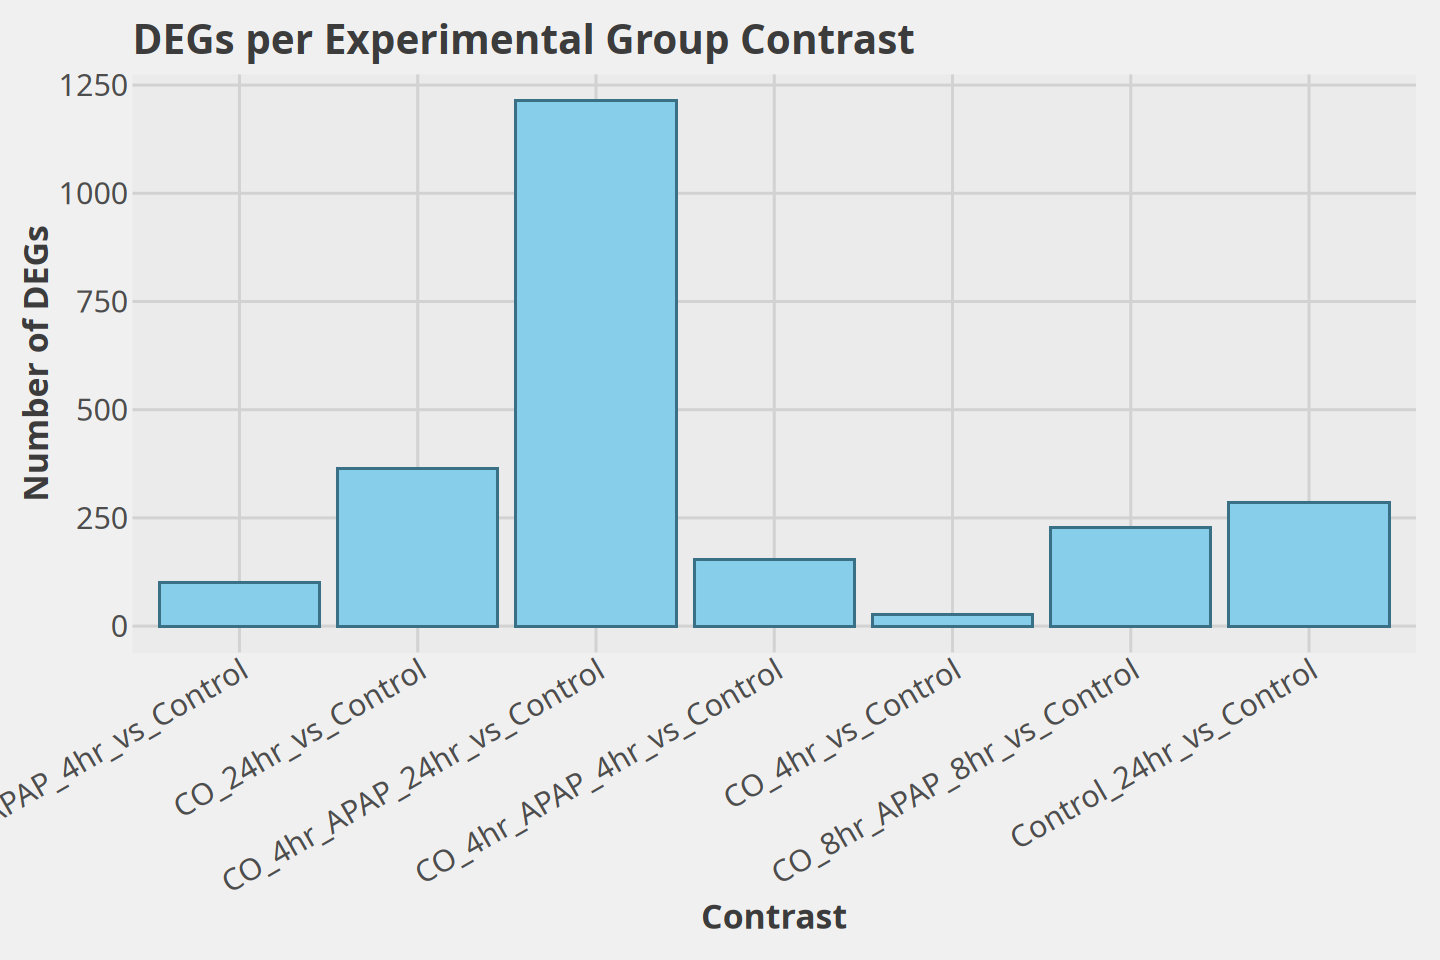

In [9]:
options(repr.plot.width = 12, repr.plot.height = 8)

expCounts <- colSums(exp_sig_mat)
expCounts_df <- data.frame(
  contrast = names(expCounts),
  count = as.numeric(expCounts)
)
print(kable(expCounts_df, format = "pandoc"))

write.csv(expCounts_df, "../de_analysis/basicContrasts_plots-tables/basicContrastCount_table.csv")

ggplot(expCounts_df, aes(x = contrast, y = count)) +
  geom_col(fill = "skyblue", color = "#397086") +
  labs(
    title = "DEGs per Experimental Group Contrast",
    x = "Contrast",
    y = "Number of DEGs"
  ) +
  theme_fivethirtyeight(base_size = 14) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
    plot.title = element_text(size = 24, face = "bold"),
    axis.title = element_text(size = 20, face = "bold"),
    axis.text = element_text(size = 18)
  )


#### **(1.b)** The following table and bar graph provide the number of DEGs found for each contrast in the "Treatment Interaction Test"




contrast                   count
------------------------  ------
co_time_4hr_vs_0hr            33
apap_time_4hr_vs_0hr         132
co_time4hr.apap_time4hr        9


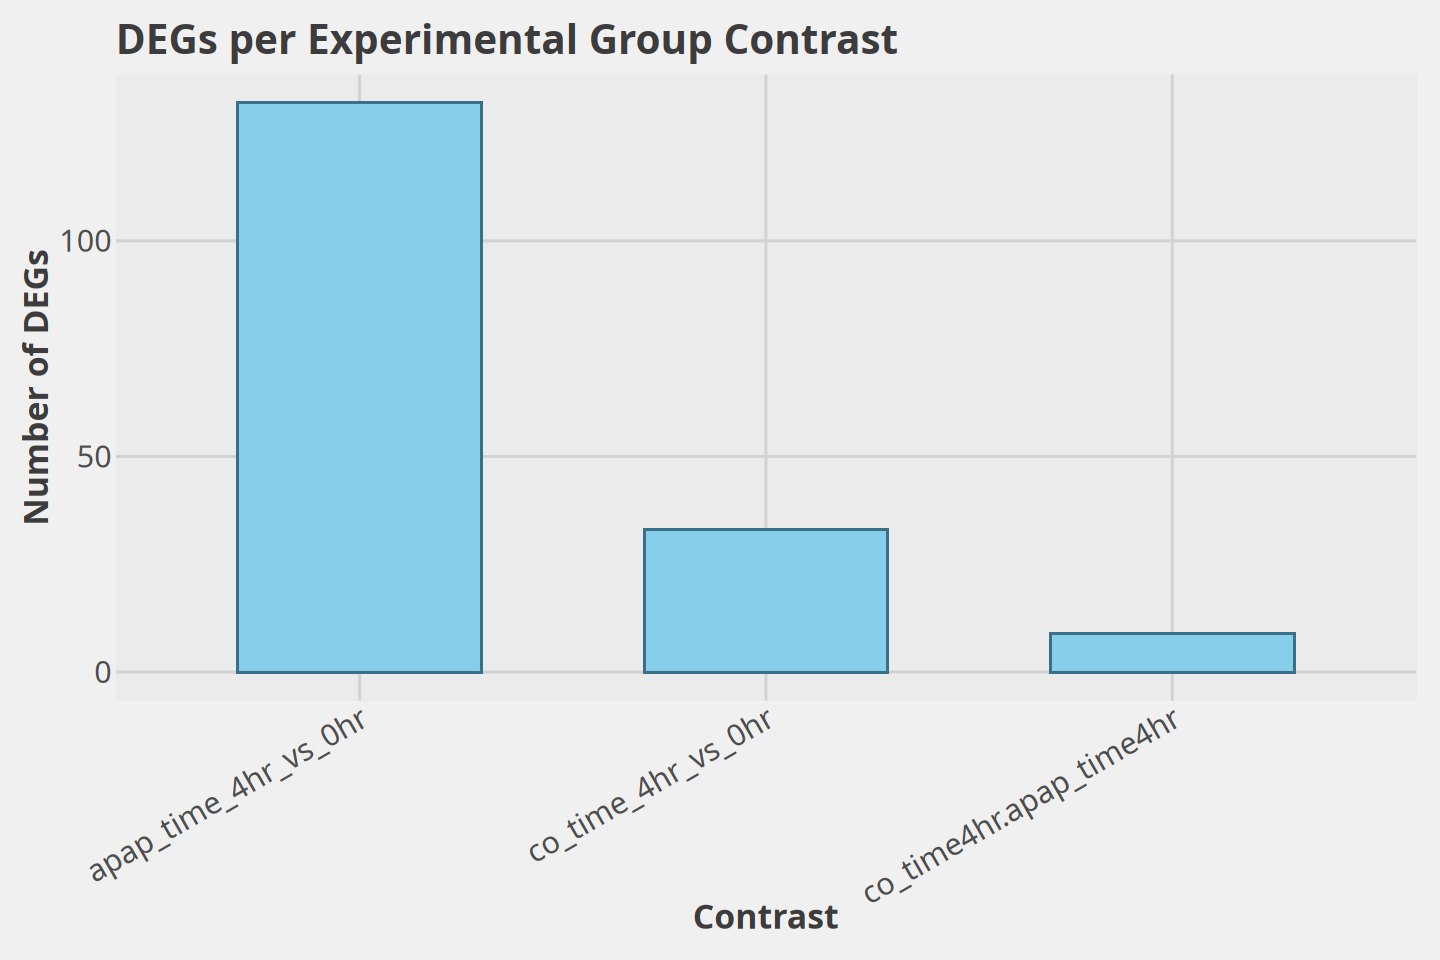

In [5]:
intCounts <- colSums(int_sig_mat)
intCounts_df <- data.frame(
  contrast = names(intCounts),
  count = as.numeric(intCounts)
)
print(kable(intCounts_df, format = "pandoc"))


ggplot(intCounts_df, aes(x = contrast, y = count)) +
  geom_col(fill = "skyblue", color = "#397086", width = .6) +
  labs(
    title = "DEGs per Experimental Group Contrast",
    x = "Contrast",
    y = "Number of DEGs"
  ) +
  theme_fivethirtyeight(base_size = 14) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        plot.title = element_text(size = 24, face = "bold"),
        axis.title = element_text(size = 20, face = 'bold'),
        axis.text = element_text(size = 18))

#### **(2.a)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

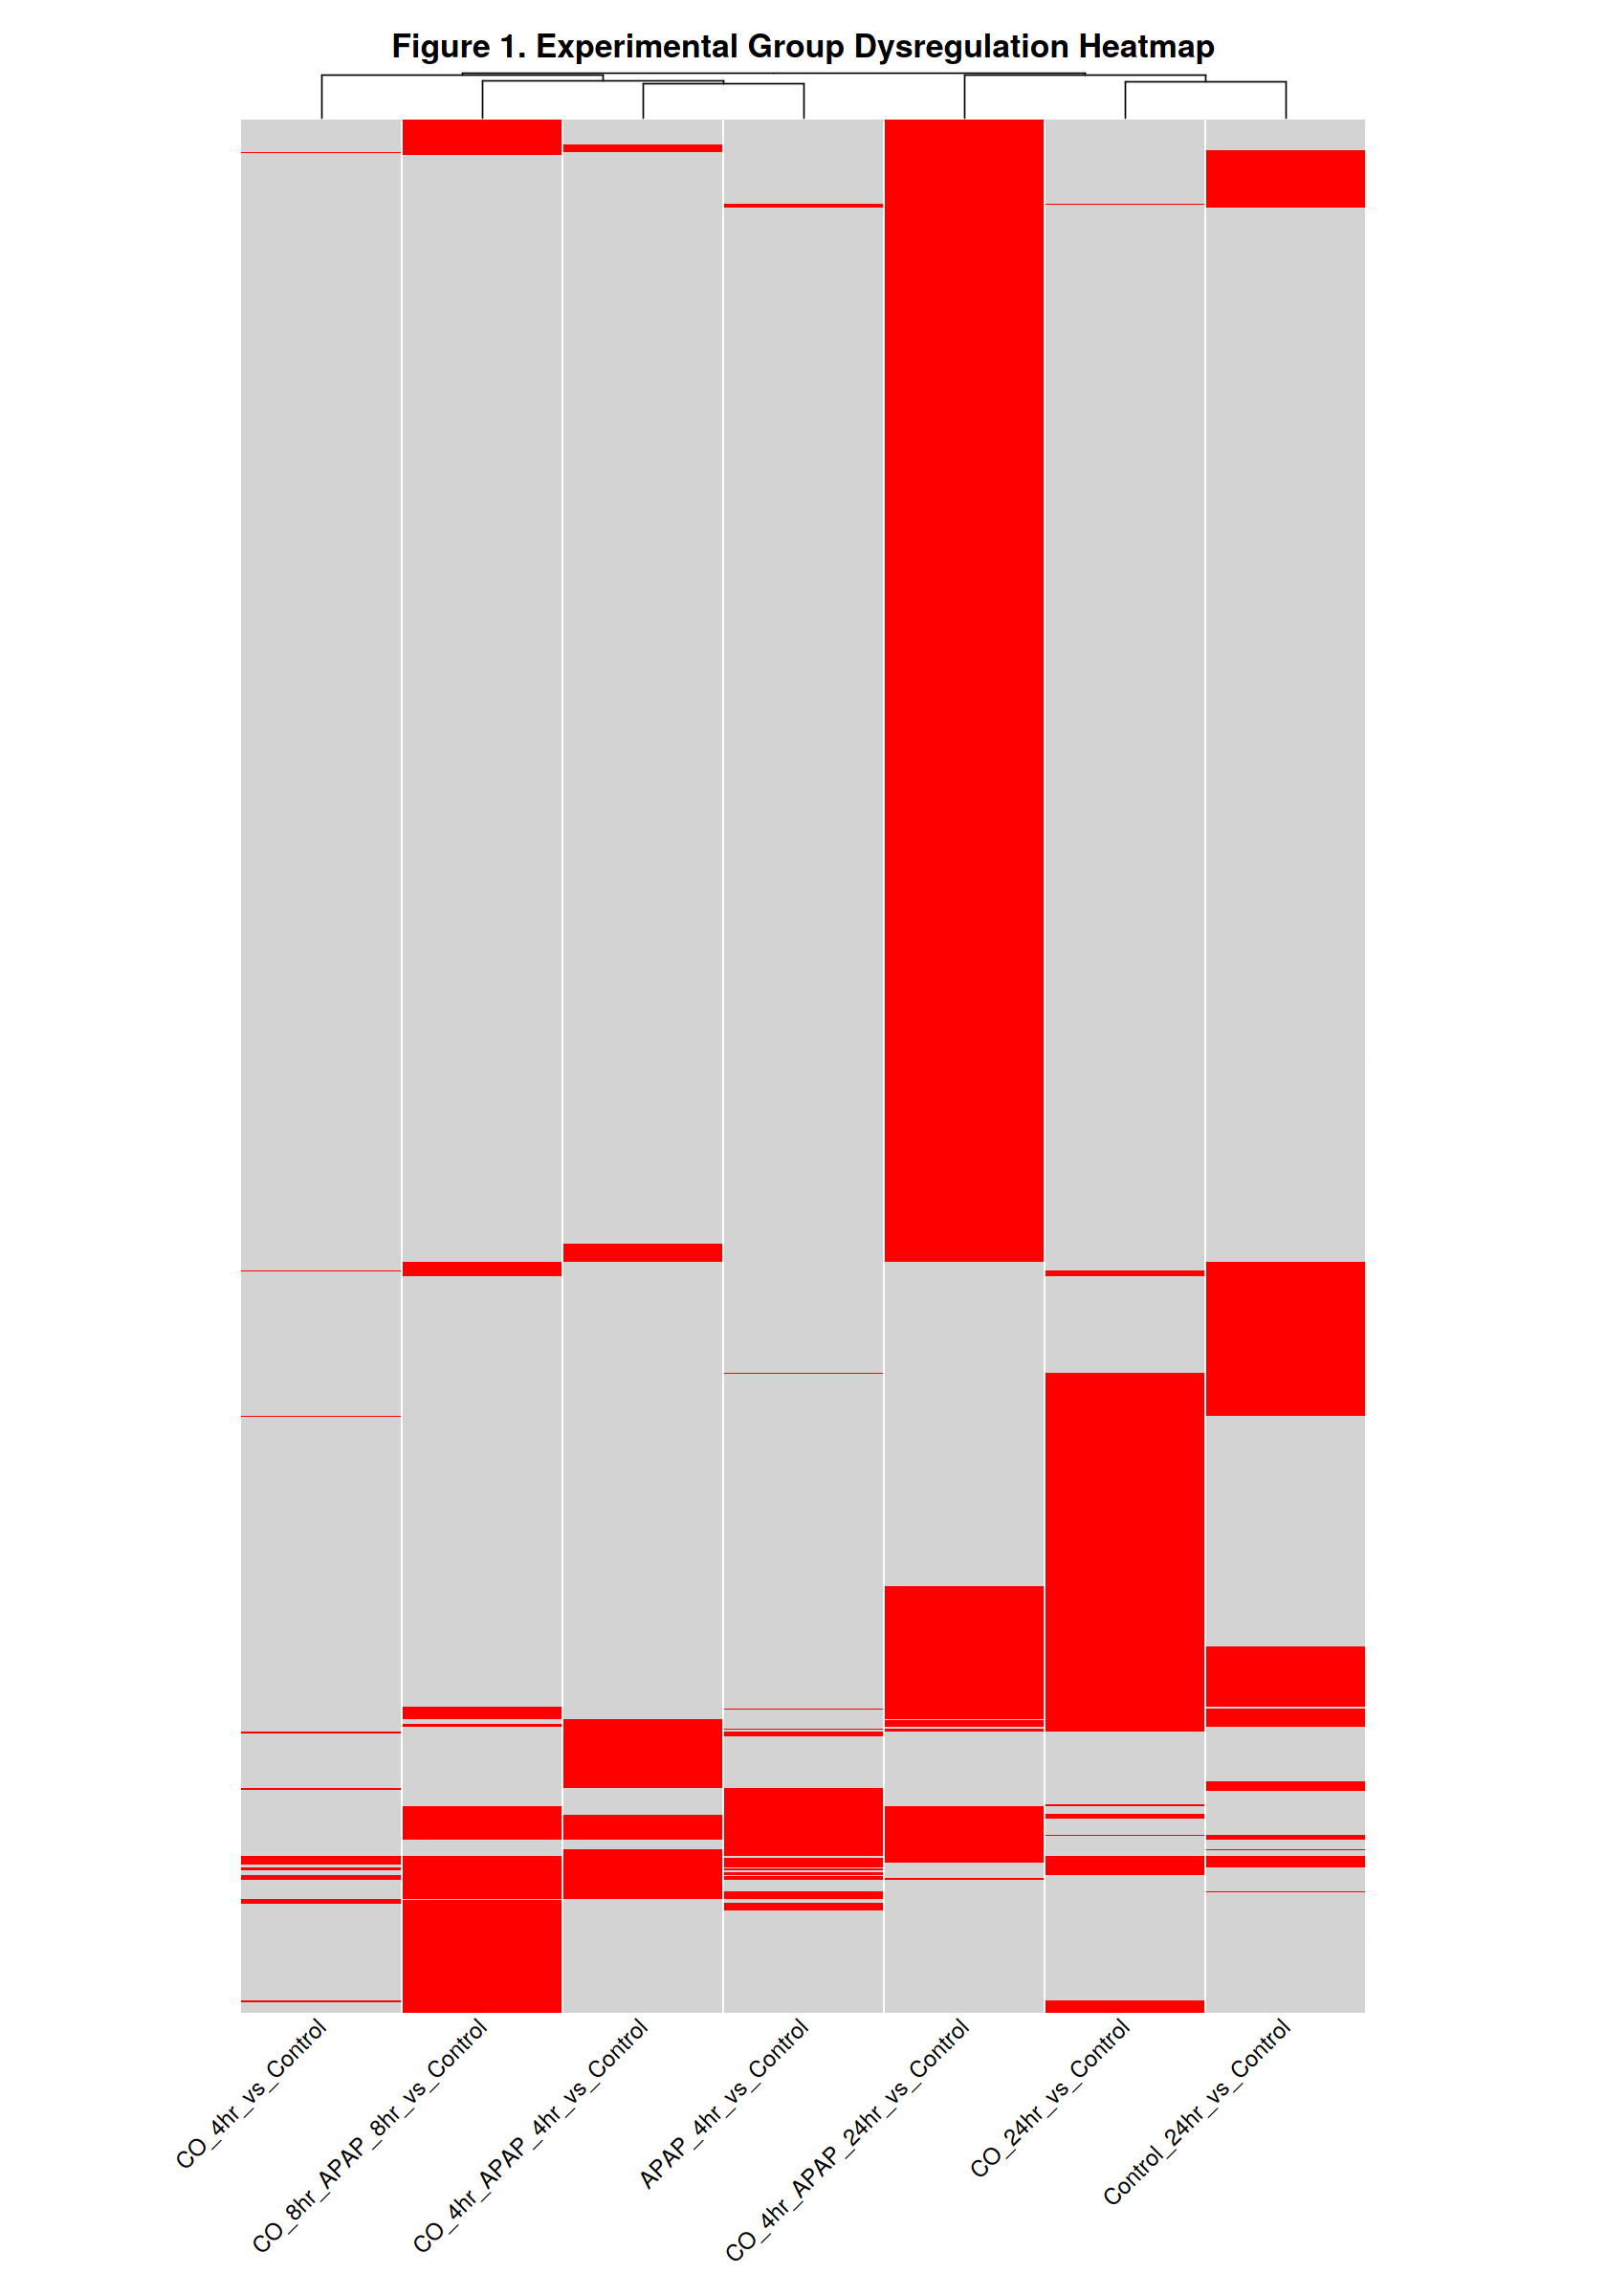

In [ ]:
width <- 14
height <- 20
options(repr.plot.width = width, repr.plot.height = height)

row_dist <- 1 - proxy::simil(as.matrix(exp_sig_mat), method = "cosine")
col_dist <- proxy::dist(t(as.matrix(exp_sig_mat)), method = "Jaccard")

# Perform hierarchical clustering with average linkage
row_hclust <- hclust(row_dist, method = "average")
col_hclust <- hclust(col_dist, method = "average")

# Determine cell width and height dynamically
n_rows <- nrow(exp_sig_mat)
n_cols <- ncol(exp_sig_mat)

ht <- Heatmap(
  as.matrix(exp_sig_mat) * 1,
  # heatmap_legend_param = list(title = NULL, legend = FALSE),
  name = "Significant",
  col = c("0" = "lightgray", "1" = "red"),

  cluster_rows = row_hclust,
  show_row_names = FALSE,
  show_row_dend = FALSE,
  show_column_names = TRUE,


  cluster_columns = col_hclust,
  column_names_rot = 45,                # angled column names
  column_title = "Figure 1. Experimental Group Dysregulation Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold"),
  column_title_side = "top",
  column_names_gp = gpar(fontsize = 14),
  width = unit(width * .7, "in"),

  show_heatmap_legend = FALSE,
  heatmap_legend_param = list(title = NULL, legend = FALSE),

  rect_gp = gpar(col = NA),             # no default cell borders
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Draw vertical white line between columns
    x_right <- convertX(x + width/2, "npc", valueOnly = TRUE)
    y_bottom <- convertY(y - height/2, "npc", valueOnly = TRUE)
    y_top <- convertY(y + height/2, "npc", valueOnly = TRUE)

    grid.lines(
      x = unit(c(x_right, x_right), "npc"),
      y = unit(c(y_bottom, y_top), "npc"),
      gp = gpar(col = "white", lwd = 1)
    )
  }
)

draw(ht, padding = unit(c(2, 4, 2, 4), "lines"))

Figure 1. is a hierarchically clustered heatmap of the full set DEGs that were found in at least one of the individual contrasts between each treatment group and the zero hour control in the experimental group test. The clustering algorithm groups genes by similarity in the binary distribution of significant expression across all of the samples. Because the data is binary, the default euclidean distance proximity measure was not used. Cosine similarity was chosen over Jaccard and Hamming as a proximity measure for genes to be clustered on. It ultimately defines the  difference between genes as the cosine of the angle between each gene when they are represented in the space formed by axes defined by the contrasts. It is directly proportional to the angle itself but can be derived without finding the angle using: 

$$cos(\theta) = \frac{\vec{x}\cdot\vec{y}}{\|\vec{x}\|\|\vec{y}\|}$$

where the vector is effectively the direction values across the contrasts for the rows representing each gene.

Cosine ensures that genes are compared in their overall pattern of direction of expression while minimizing the influence of the number of times that they are perturbed and in doing so makes the direction perturbation more impactful. Jaccard similarity is used for the clustering of contrasts where they are grouped based on where there is agreement on what genes are DEGs rather than what genes are not. While the genes are not articulated explicitly in the heatmap, the clustering technique effects how they are displayed providing an means to compare the expression patterns associated with each contrast group. The heatmap shows disparity in the number of genes associated with perturbation captured for each contrast, where the 4 hour co-extract with 24 hour acetaminophen exposures yielded the greatest amount of significant gene expression perturbation while the 4 hour exposure to the extract with no acetaminophen showed the least perturbation.

There are two experimental groups that were exposed only to co-extract: for 4 hours and 24 hours respectively. The general disparity in the genes with significant perturbation in these two groups might indicate different states of cellular activity at these different levels of exposure. This interpretation of disparity is fortified by the clustering distances between these contrasts in the horizontal dendrogram at the top of the heatmap. This could suggest that the effects of the extract does not perpetuate specific cellular functions over the length of exposures being studied for co-extract, but potentially reflects a progression of expression patterns over different time intervals. This will be assessed in downstream analysis.

More agreement can be seen between experimental groups that were exposed to both the extracts for the same amount of time: 4 hours and 8 hours, respectively. There is more similarity between these experimental groups than the groups exposed only to the co-extract, being clustered together at a lower level of the dendrogram and having more overlap in the gene groups that showed significant expression. There is about as much similarity between the 4 hour bi-treatment group and the 4 hour acetaminophen-only treatment group as there is between the 4 and 8 hour bi-treatment groups. Given the relative similarity between these three groups compared to the amount of similarity with the 4 hour extract-only group, might suggest that there is a reductive effect on the disregulation occurring due to acetaminophen when exposed to co-extract. On the other hand, it could mean that the independent contribution to overall perturbation due the extract is simply less than that due to the acetaminophen without having a reductive effect. It will be difficult to parse the implications of these observations in downstream analysis due to the need for opportunity to distinguish the independent effects of both treatments at the 8 hour level. 

These observations do not in any way rule out the interactive effect of the treatments on functional activity that might be occurring in response to the exposure. At this level of analysis it is not possible to clarify genes that are known to participate in the same pathways as being significantly expressed. It is possible that the gene level clustering has identified some true biological signal but is much more likely that it reveals more information about the relationships between samples, than it does about relationships between genes. Downstream analysis will be performed for more robust clustering analysis. Additionally, this is a categorical level analysis that is meant to offer perspective on data that will be used to identify genes whose expression patterns perpetuate across multiple contrasts. This is a bird's eye view that may have more meaning in context with other analysis.

#### **(2.b)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

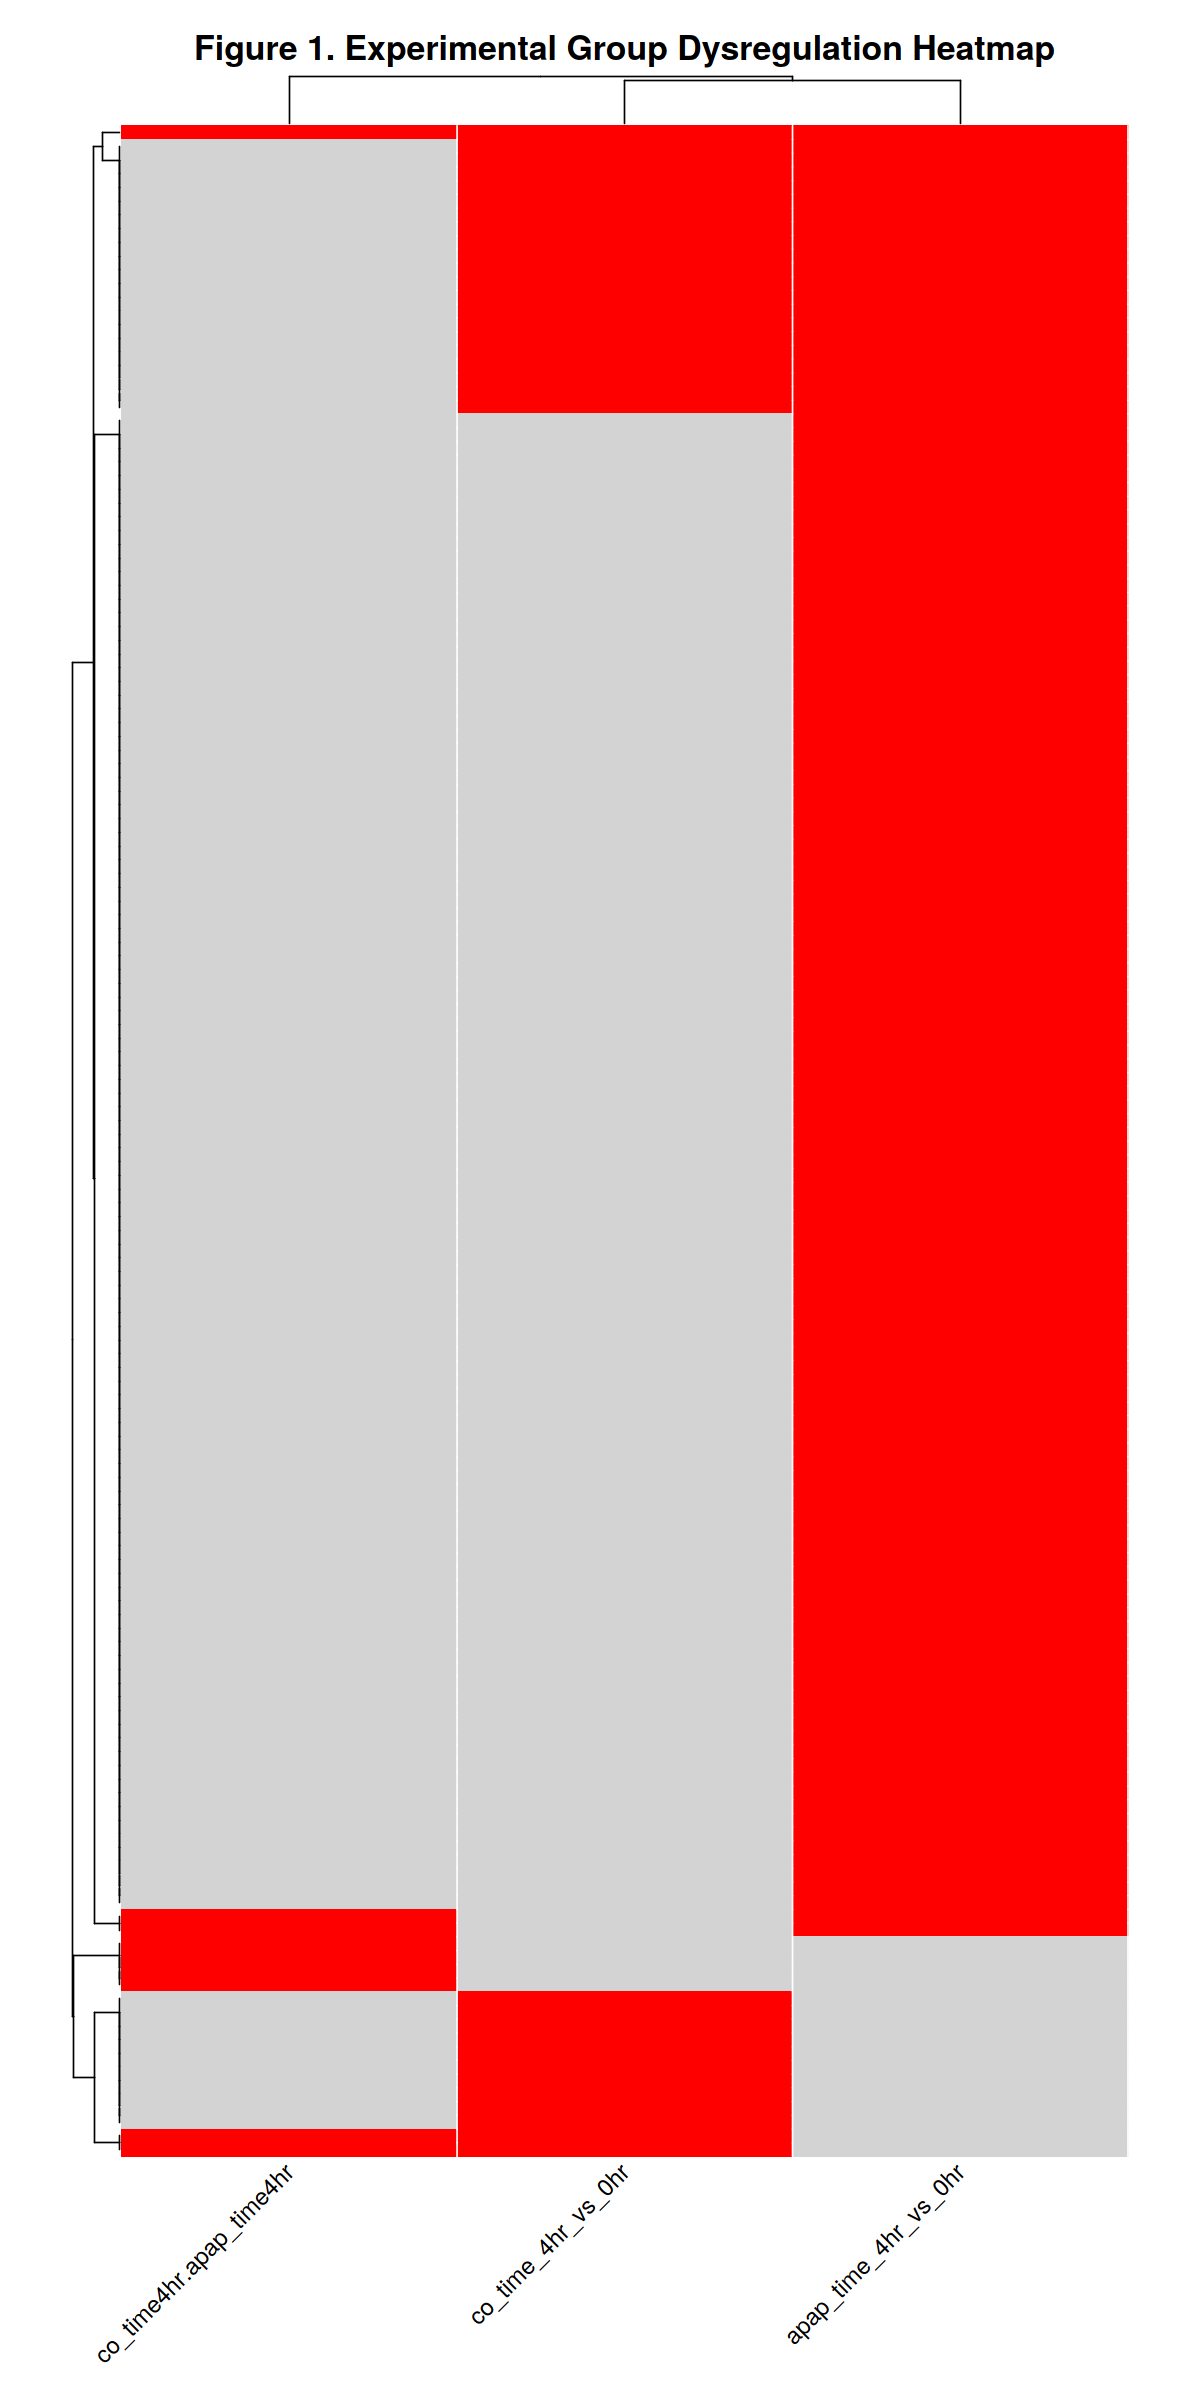

In [7]:
options(repr.plot.width=10, repr.plot.height=20)

row_dist <- proxy::dist(as.matrix(int_sig_mat), method = "Jaccard")
col_dist <- proxy::dist(t(as.matrix(int_sig_mat)), method = "Jaccard")

# Perform hierarchical clustering with average linkage
row_hclust <- hclust(row_dist, method = "average")
col_hclust <- hclust(col_dist, method = "average")

# Determine cell width and height dynamically
n_rows <- nrow(int_sig_mat)
n_cols <- ncol(int_sig_mat)

ht <- Heatmap(
  as.matrix(int_sig_mat) * 1,
  # heatmap_legend_param = list(title = NULL, legend = FALSE),
  name = "Significant",
  col = c("0" = "lightgray", "1" = "red"),
  cluster_rows = row_hclust,
  cluster_columns = col_hclust,
  show_row_names = FALSE,
  show_column_names = TRUE,
  column_names_rot = 45,                # angled column names
  column_title = "Figure 1. Experimental Group Dysregulation Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold"),
  column_title_side = "top",
  show_heatmap_legend = FALSE,   
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 8),
  rect_gp = gpar(col = NA),             # no default cell borders
  # padding = unit(c(2, 2, 2, 2), "cm"), # top, right, bottom, left
  heatmap_legend_param = list(title = NULL, legend = FALSE),  # remove legend
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Draw vertical white line between columns
    x_right <- convertX(x + width/2, "npc", valueOnly = TRUE)
    y_bottom <- convertY(y - height/2, "npc", valueOnly = TRUE)
    y_top <- convertY(y + height/2, "npc", valueOnly = TRUE)

    grid.lines(
      x = unit(c(x_right, x_right), "npc"),
      y = unit(c(y_bottom, y_top), "npc"),
      gp = gpar(col = "white", lwd = 1)
    )
  }
)

draw(ht, padding = unit(c(2, 4, 2, 4), "lines"))

Figure 2. is a hierarchically clustered heatmap of the full set of DEGs that were found in any of the individual contrasts from the interaction test. The test was performed on a subset of samples restricted to exposures intervals of 0-4 hours for both treatments. This test was conducted as a robust means to identify DEGs that are expressed at levels statistically significant beyond was can be explained by the treatments independently. However, the circumstances under which the test was conducted leave doubt in the accuracy of its results. Due to the full rank requirement for the predictive matrix made for generating a test statistic, the number of samples were less than ideal for this test which could lead to type II errors (failing to reject the null). It is possible that there are more genes whose expression in the presence of both treatments was different to a statistically significant level than what occurs as a result of each treatment independently. In addition, the fact that the maximum exposure was limited to 4 hours for each treatment can further confound the results since it is evident when looking at all of the contrasts to the 0 hour control across the treatment groups that maximum perturbation does not occur at 4 hour exposure mark. Relaxing the statistical threshold for rejecting the null is not sufficient because it implicitly assumes that the distribution the test is conducted in would be the same if there were additional samples for higher exposure times. As a consequence the analysis of interactivity will not consider the results of this test. 


#### **(3.a)** The following quantifies and identifies DEG membership in each of the set intersections that exist between experimental group contrasts. The plot was created using the ComplexUpset library. The underlying data object that is generated from the experimental group test's significance matrix by the upset() function is then used for subsequent analysis and the identities of the DEGs in each of the intersections that exist between the contrasts. 

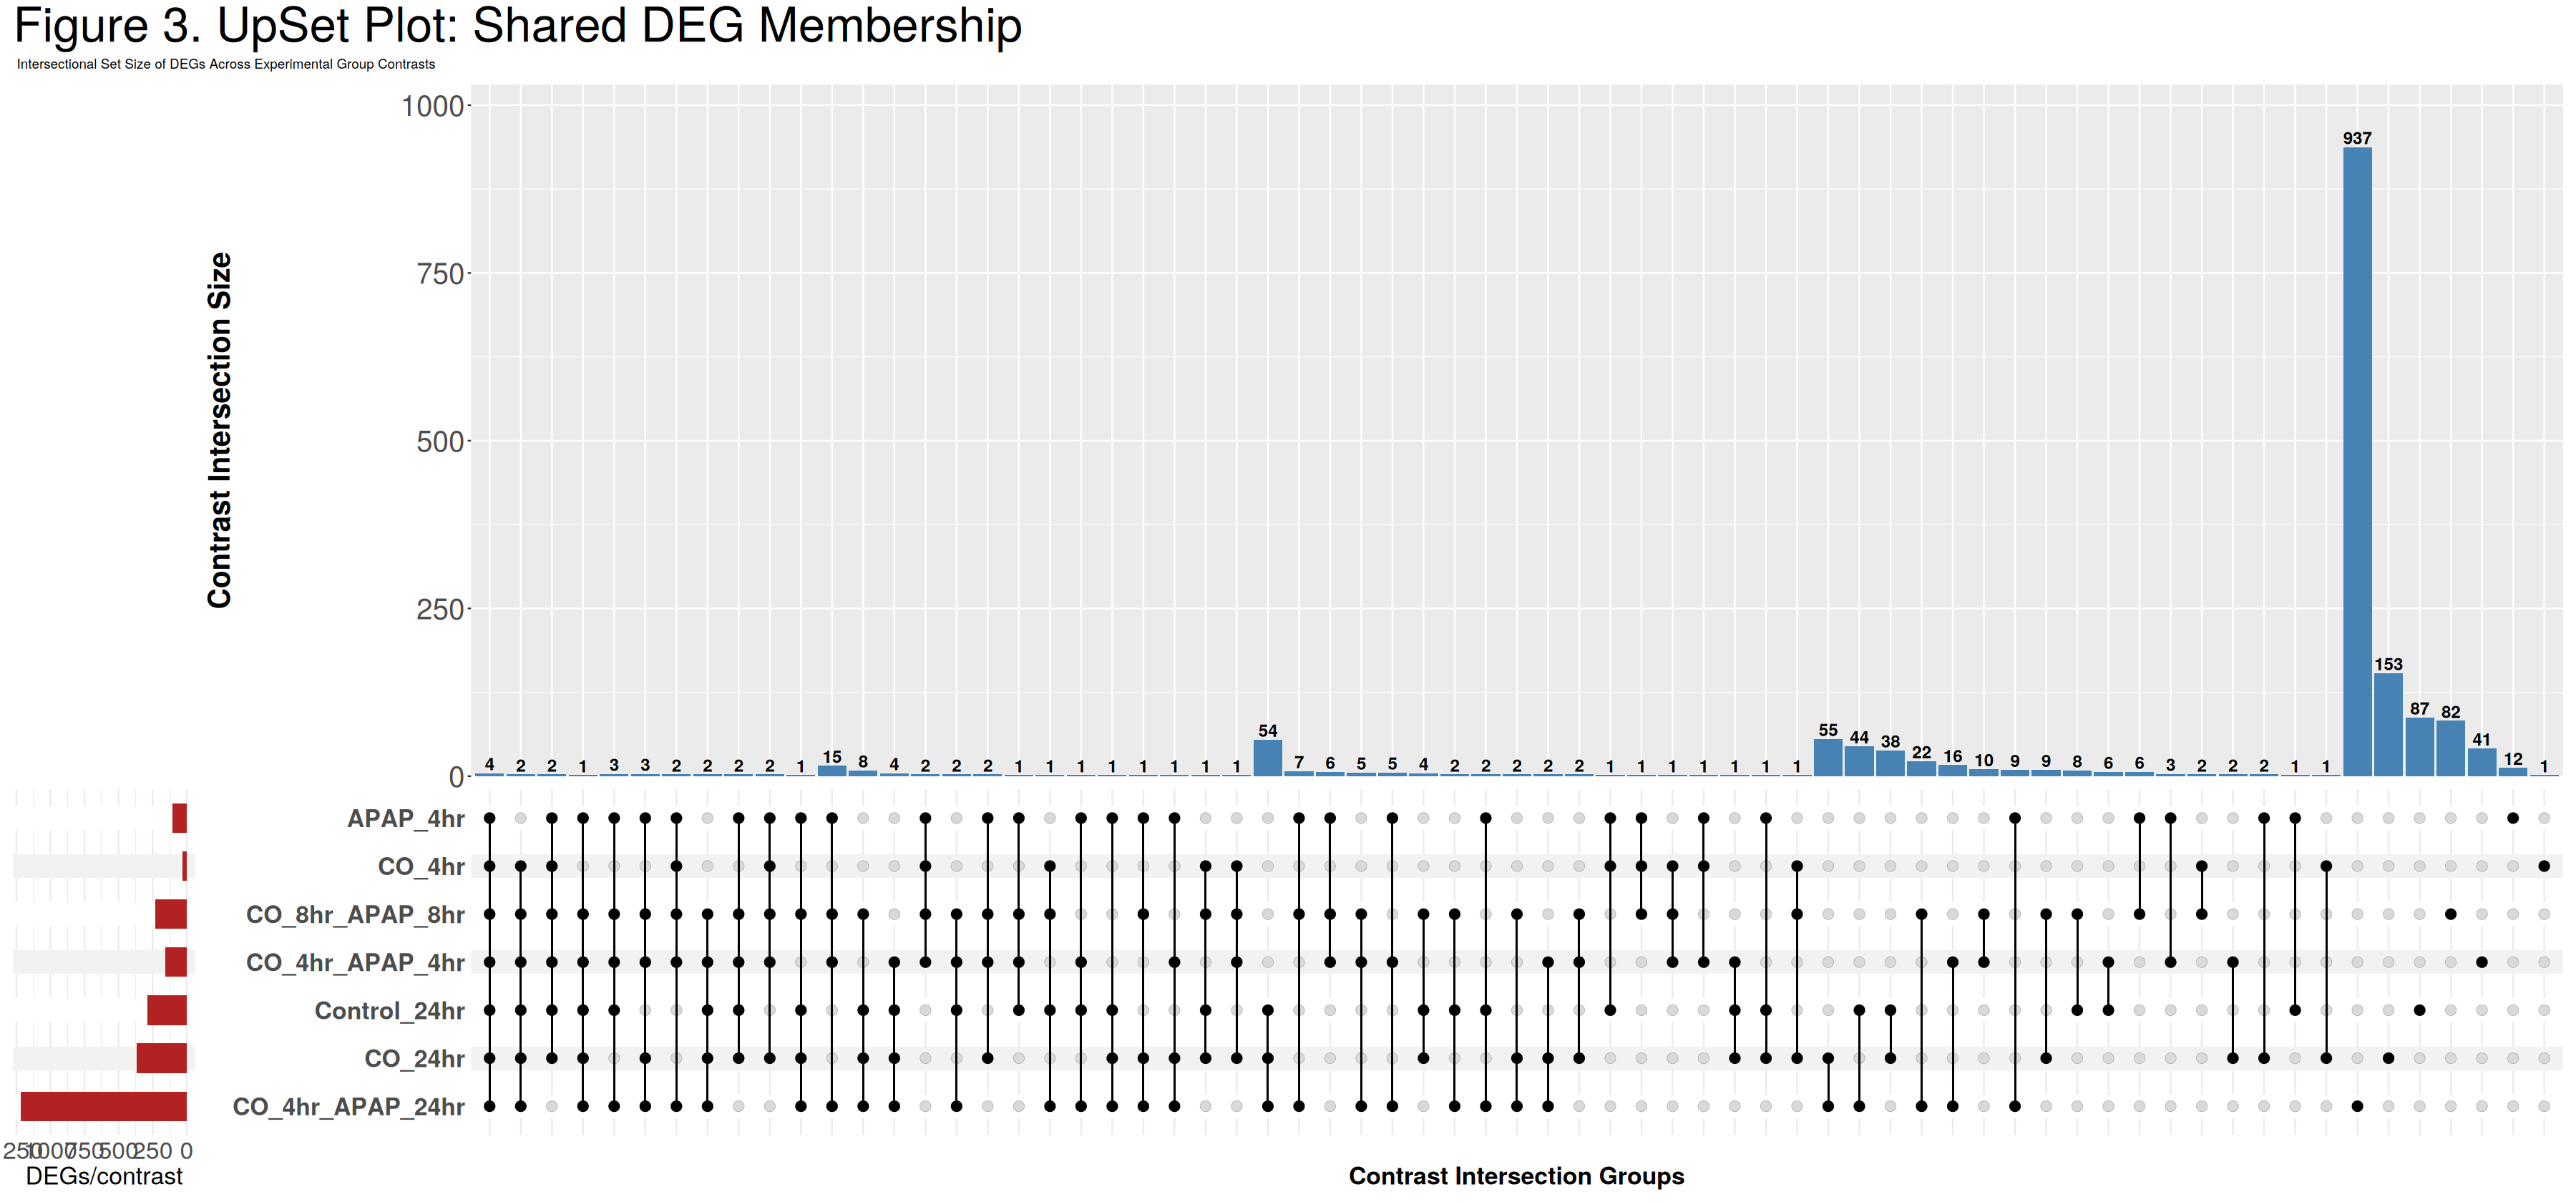

In [22]:
#
options(repr.plot.width=30, repr.plot.height=14)

upSet_df <- as.data.frame(exp_sig_mat)
colnames(upSet_df) <- sub("_vs_.*", "",
          colnames(upSet_df), 
          ignore.case = TRUE)

p = upset(
  upSet_df,
  intersect = colnames(upSet_df),
  name = "Contrast Intersection Groups", # names matrix
  base_annotations = list(
    # names vertical bars
    'Contrast Intersection Size' = intersection_size(
      counts = TRUE,
      bar_number_threshold = 1, # ensures that counts at top of bar
      mapping = aes(fill = 'intersection'),
      text = list(
        color = 'black', # Forces the text to be black instead of white
        size = 5,
        fontface = "bold"         # Optional: adjust the font size of the numbers
      )
    ) + 
    # 0.3 (30%) expansion gives the 1013 bar enough "sky" to breathe
    scale_y_continuous(expand = expansion(mult = c(0, 0.1)))
  ),

  set_sizes = upset_set_size(
    mapping = aes(fill = 'set')) +
    ylab("DEGs/contrast"), # names horizonal bars

  min_size = 1,
  sort_sets = FALSE,
  sort_intersections_by = c('degree','cardinality'), # orders by intersection degree and then frequency in intersection
  width_ratio = 0.08,
  
  themes = upset_modify_themes(
    list(
      # Targets the side bar chart (Set sizes)
      'overall_sizes' = theme(axis.text.x = element_text(size = 20),
                              axis.title.x = element_text(size = 20)),
      
      # Targets the top bar chart (Intersection sizes)
      'Contrast Intersection Size' = theme(axis.text.y = element_text(size = 24),
                                  axis.title.y = element_text(size = 24, face = "bold"),
                                  axis.text.x = element_blank(),
                                  axis.ticks.x = element_blank(),
                                  axis.title.x = element_blank() 
                                  ),
      
      # Targets the dot matrix labels (Set names)
      'intersections_matrix' = theme(axis.text.y = element_text(size = 20, face = "bold"),
                                  axis.text.x = element_blank(),
                                  axis.title.x = element_text(size = 20,face = "bold")
                                )
    )
  )
  
) & scale_fill_manual( # Use '&' instead of '+' to apply to all sub-plots
  values = c(
    'intersection' = "steelblue",
    'set' = "firebrick"
  ),
  breaks = c('intersection', 'set') # Explicitly define breaks to avoid level mismatch
) & 
theme(legend.position = "none")

p + plot_annotation(title = "Figure 3. UpSet Plot: Shared DEG Membership",
  subtitle = "\tIntersectional Set Size of DEGs Across Experimental Group Contrasts",
  # caption = "put caption here",
  theme = theme(plot.title = element_text(size = 40))
)


Figure 3. is an "UpSet" plot that reveals the same information you would expect from venn diagrams but as a cleaner visual interface for the significant number of intersections that exist between the experimental group contrasts. 

The blue bars show the number of DEGs that exist in a given intersection and the points in the matrix underneath indicate the contrasts contributing to the intersection set. In other words, if there is a point in the column associated with the vertical bar above it the contrast for the row with that point contributes to the intersection. The order of the Contrast Intersection Groups is by the number of the contrasts that contribute to the intersection. The first vertical bar are the number of DEGs found in the intersection of all contrasts (degree 7), the next set of bars are the DEG set-sizes for the intersections that exist between any six of the contrasts (degree 6), followed by the next set of bars that apply to contrast intersections of degree 5, and so on. (You can see in the vertical plot where there is a jump in the bar heights, which identifies the start of a new degree of intersection for contributing contrasts). The last set of bars on the far right represent the size of the set of DEGs that belong to a given contrast and no other contrasts.  

The red bars give you a reference point for appreciating the magnitudes of the intersections that include a given contrast by providing a relative sense of the number of DEGs found in each contrast overall. There is a strong correlation between the number of DEGs identified for a contrast and the number of intersections that each contrast contributes to.

Most identified DEGs are identified exclusively for a single contrast. The largest set of the contrast-exclusive sets was that identified for the CO_4hr_APAP_24_hr contrast containing 1017 DEGs unique to it, followed by the CO_24hr contrast with 192 unique DEGs and then the Control_24hr contrast with 102 unique DEGs. The smallest of the contrast-exclusive sets was that identified for the co_4hr group containing 2 DEGs unique to it. There were 4 DEGs identified to be in all contrasts, 15 exclusive DEGs found in all contrasts that included acetaminophen and 0 DEGs found in all contrasts including the extract (1 DEG was found across all of the contrasts including the extract if you exclude the 4 hour exposure treatment group). The intersection of  63 DEGs that were shared between the 24 hour exposure to the extract alone and the 4 hour extract exposure with 24 acetaminophen exposure. The table below includes the number of instances each contrast is included in an intersection between contrasts that had at least one shared DEG.

**It is important to consider when interpreting this plot that the genes which are included in a given intersection are assigned to the highest degree intersection to which they belong but always implicitly belong to the intersection of each subset of contrasts identified for that intersection included in the plot. The plot is designed to account for each data object (in this case DEG) that is in the data being evaluated for intersections so that the summed number in the counts associated with the blue bars equals the total number of DEGs.** For example, each of the 65 DEGs found to be unique to the intersection of the (24 hour control) $\cap$ (24 hour extract) $\cap$ (4 hour extract with 24 hour acetaminophen) intersection is also by extension part of the set of DEGs in the (24 hour control) $\cap$ (24 hour extract) intersection and the (24 hour control) $\cap$ (4 hour extract with 24 hour acetaminophen) intersection. It this should factor into evaluations of what belongs to lower degree intersections. This does mean that those member genes are found to be significant for each of those contrasts independent of one another as well. However, it is important to account for the context. Since the 65 DEGs are found in the 24 hour control group, and the medium is present in the other 24 hour extract groups in the experiment, it is appropriate to attribute the differential expression of those genes DEGs to the medium itself. In another instance there are 15 DEGs found to be exclusive to the intersection of all groups containing acetaminophen but there are 7 DEGs that are additionally exclusive to all acetaminophen-exposed groups except the 8 hour exposure. Given that this exposure is a somewhat central value in the intervals of exposure to acetaminophen in this experiment, it is appropriate to ask if the additional 7 DEGs intermittent presence in these contrasts are true signal or if they are in fact can be explained by something technically derived. The fact that these distinctions can be articulated from the ComplexUpset plot is part of its value. 

#### **(3.b)** The following is a table that indicates the number of intersections each of the contrasts provided content for

In [9]:
upset_info <- upset_data(upSet_df, colnames(upSet_df))
unique_intersections <- unique(upset_info$with_sizes[, colnames(upSet_df)])
participation_counts <- as.data.frame(colSums(unique_intersections))
colnames(participation_counts) <- c("Intersection Inclusion Count")
participation_counts["Contrast"] <- rownames(participation_counts)
rownames(participation_counts) <- NULL
participation_counts <- participation_counts[,c(2,1)]
print(kable(participation_counts, format = "pandoc"))



Contrast            Intersection Inclusion Count
-----------------  -----------------------------
CO_4hr_APAP_24hr                              31
CO_24hr                                       32
Control_24hr                                  29
CO_4hr_APAP_4hr                               33
CO_8hr_APAP_8hr                               38
CO_4hr                                        17
APAP_4hr                                      31


#### **(3.c)** The following are tables that clarify the inclusive set of genes found between the intersections of the contrasts. (This is a very large table with a comprehensive set of DEG lists indicating what belongs to each contrast intesection).

The data object that is used to create the UpSet visuals contains a number of data frames. "with_sizes" is a data frame that includes an attribute called "exclusive_intersection" that provides a string representation of the unique intersection of contrasts each DEG belongs to. This is exported to the de_analysis folder in this pipeline as "shared_degs.csv". The "exclusive_intersection" attribute's unique values are used to identify the genes that belong to intersections exclusively. The values of "exclusive_intersection" are built be concatenating the names of all the contrasts in which each gene is found, thus short circuiting the path required for "intersection of intersections" operations in order to identify exclusive sets. To find inclusive sets of genes for a given intersection that incorporates genes with higher degree intersection allocations through the "exclusive_intersection" value derivation scheme, recursive filtering of the "with_sizes" data frame based on pattern matches of each unique value in the "exclusive_intesection" attribute against the whole vector of values in the "exclusive_intersection" column of the data frame is performed. Using pattern matches ensures that genes whose "exclusive_intersection" value that contains the searched pattern is also in the inclusive set being derived, not just those genes with the exact value. For the genes that are exclusive to the highest degree intersection, its "exclusive_intersection" value will only match the exact value itself, but "exclusive_intersection" value for any gene of a lower degree intersection will also match the highest degree intersection as well. This holds true for any gene exclusive to a lower degree intersection that contributes a higher degree intersection. This builds an inclusive set of DEGs for every intersection which can better clarify relationships of functionality associated with each treatment in the experiment by looking at these specific intersections based on the contrasts that informed on them. The results are previewed below and the full results are exported to csv.

In [10]:
intersect_df = upset_info$with_sizes
unique_intersections <- unique(intersect_df$exclusive_intersection)
unique_intersections <- sort(setNames(unique_intersections, unique_intersections)) # names members as member string

# Generates a list of intersections and their membership as gene symbols. 
# (Prior list is ensemble ids). 
# The resulting list has some NAs due to their being no gene_symbol associated with the ensemble id
get_inclusive_set <- function(intersection, intersection_df){

  match_pattern <- paste0("(^|-)", intersection, "(-|$)")
  
  # subset the df using the strict pattern
  internal_df <- intersection_df[grepl(match_pattern, intersection_df$exclusive_intersection),]
  # get identifiers from df as vector
  members <- rownames(internal_df)
  # strip upset's added extensions to the identifiers
  members <- gsub("(\\.[0-9]+)\\.[0-9]+$", "\\1", members)
  # reduce the vector to unique members
  members <- unique(members)
  # return unique members
  return(members)
}

inclusive_membership <- lapply(unique_intersections, get_inclusive_set, intersection_df = intersect_df)

inclusive_size <- sapply(inclusive_membership, function(x) {
  length <- length(x)
})

get_exclusive_set <- function(intersection, intersection_df){

  # subset the df using the strict pattern
  internal_df <- intersection_df[intersection_df$exclusive_intersection == intersection, ]
  # get identifiers from df as vector
  members <- rownames(internal_df)
  # strip upset's added extensions to the identifiers
  members <- gsub("(\\.[0-9]+)\\.[0-9]+$", "\\1", members)
  # reduce the vector to unique members
  members <- unique(members)
  # return unique members
  return(members)
}

exclusive_membership <- lapply(unique_intersections, get_exclusive_set, intersection_df = intersect_df)

inclusive_size <- sapply(inclusive_membership, function(x) {
  length <- length(x)
})

exclusive_size <- sapply(exclusive_membership, function(x) {
  length <- length(x)
})

temp_df <- cbind(unique_intersections, inclusive_size, exclusive_size)

rownames(temp_df) <- NULL

temp_df

unique_intersections,inclusive_size,exclusive_size
APAP_4hr,101,12
CO_24hr,365,153
CO_24hr-APAP_4hr,2,2
CO_24hr-CO_4hr,1,1
CO_24hr-CO_4hr_APAP_4hr,15,2
CO_24hr-CO_4hr_APAP_4hr-CO_8hr_APAP_8hr,10,2
CO_24hr-CO_4hr_APAP_4hr-CO_8hr_APAP_8hr-APAP_4hr,5,2
CO_24hr-CO_4hr_APAP_4hr-CO_8hr_APAP_8hr-CO_4hr,3,1
CO_24hr-CO_4hr_APAP_4hr-CO_8hr_APAP_8hr-CO_4hr-APAP_4hr,2,2
CO_24hr-CO_8hr_APAP_8hr,13,9


In [23]:
# Turns the membership lists into symbols
symbol_map <- df[, c('Geneid','gene_symbol')]

get_member_symbols <- function(membership_list, map){
  # subset map to include genenids in membership list
  symbols <- map[map$Geneid %in% membership_list,]$gene_symbol
  return(symbols)
}

intersection_inclusive_symbols <- lapply(inclusive_membership, get_member_symbols, map = symbol_map)
intersection_exclusive_symbols <- lapply(exclusive_membership, get_member_symbols, map = symbol_map)

In [24]:
#### concatenates the list of genes for each contrast intersection into a tabel

# 1. inclusive sets

# creates table of genes per intersection by ensemble id
ensembl_inclusive_df <- stack(inclusive_membership)
ensembl_inclusive_df <- aggregate(values~ind, data = ensembl_inclusive_df, FUN = function(x) paste(x, collapse = ", "))
colnames(ensembl_inclusive_df) <- c("Intersection", "Inclusive_Members")
# creates table of genes per intersection by symbol
symbol_inclusive_df <- stack(intersection_inclusive_symbols)
symbol_inclusive_df <- aggregate(values ~ ind, data = symbol_inclusive_df, FUN = function(x) paste(x, collapse = ", "))
colnames(symbol_inclusive_df) <- c("Intersection", "Inclusive_Members")


#2. exclusive sets
ensembl_exclusive_df <- stack(exclusive_membership)
ensembl_exclusive_df <- aggregate(values~ind, data = ensembl_exclusive_df, FUN = function(x) paste(x, collapse = ", "))
colnames(ensembl_exclusive_df) <- c("Intersection", "Exclusive_Members")

symbol_exclusive_df <- stack(intersection_exclusive_symbols)
symbol_exclusive_df <- aggregate(values ~ ind, data = symbol_exclusive_df, FUN = function(x) paste(x, collapse = ", "))
colnames(symbol_exclusive_df) <- c("Intersection", "Exclusive_Members")


#### Intersection Tables

Preview of ensemble id lists of genes in each inclusive and exclusive intersection. (The intersections match those in the prior plot but the remember that these intersections are inclusive while the plot is exclusive). To check the validity, compare to the table created earlier for membership in individual contrasts. This matches the number of genes in these tables for the contrasts by themselves. 

This is the intersection memebership data frame with symbols. There were ensemble ids that don't have gene symbols associated with them, so this is a slightly less accurate list (vast majority of members had symbols)

#### **Table 1. Inclusive Table (Gene Symbols)**

In [ ]:

symbol_inclusive_df

#### **Table 2. Inclusive Table (Ensemble IDs)**

In [ ]:
ensembl_inclusive_df

#### **Table 3. Exclusive Table (Ensemble IDs)**

In [ ]:
symbol_exclusive_df

#### **Table 4. Exclusive Table (Gene Symbols)**

In [ ]:
symbol_exclusive_df

In [ ]:
full_membership_df <- ensembl_inclusive_df
full_membership_df['inclusive_member_symbols'] <- symbol_inclusive_df$Inclusive_Members
full_membership_df['inclusive_size'] <- inclusive_size
full_membership_df['Exclusive_Members'] <- ensembl_exclusive_df$Exclusive_Members
full_membership_df['exclusive_member_symbols'] <- symbol_exclusive_df$Exclusive_Members
full_membership_df['exclusive_size'] <- exclusive_size


In [ ]:
write.csv(full_membership_df, "../de_analysis/basicContrasts_plots-tables/basicContrast_intersection_membership.csv")

___
___

## II. Direction Level Analysis


This section analyzes patterns in direction of expression across experimental group contrasts. This provides insight into how the DEGs varied across the contrasts and what this may imply about relationships between treatment groups. The analysis relies on a matrix using the same DEG candidates and contrasts but encode the direction of disregulation where values encode up regulation ("1"), no significance ("0"), and down regulation ("-1"). The rest of the analyses in this section rely on this matrix.

In [13]:
# create the directional matrix for experimental group test data
exp_directionCols <- grep("significance", colnames(exp_df), value = TRUE)

# subsets to columns with 'significance' extension
exp_dir_mat <- exp_df[,exp_directionCols]
# removes 'significance' extension from names
colnames(exp_dir_mat) <- gsub(".significance", "", colnames(exp_dir_mat))
colnames(exp_dir_mat) <- gsub("groupTest_", "", colnames(exp_dir_mat))

# updates values to numeric representation
exp_dir_mat[exp_dir_mat == 'upregulated'] <- 1
exp_dir_mat[exp_dir_mat == 'downregulated'] <- -1
exp_dir_mat[exp_dir_mat == 'not significant'] <- 0

# remove non-significant genes
exp_dir_mat <- exp_dir_mat[rowSums(exp_dir_mat != 0) > 0, ]

# checks results
print(head(exp_dir_mat))
cat("\n\nNumber of NA: ", sum(is.na(exp_dir_mat)))
cat("\n\nNumber of DEGs: ", nrow(exp_dir_mat))
cat("\n\nNumber of 0's: ", sum(exp_dir_mat == 0))
cat("\nNumber of 1's: ", sum(exp_dir_mat == 1))
cat("\nNumber of -1's: ", sum(exp_dir_mat == -1))


                   CO_4hr_APAP_24hr_vs_Control CO_24hr_vs_Control
ENSG00000075624.17                          -1                 -1
ENSG00000125148.7                           -1                 -1
ENSG00000184009.13                          -1                 -1
ENSG00000177410.14                           1                  0
ENSG00000234741.11                           1                  0
ENSG00000135480.17                          -1                 -1
                   Control_24hr_vs_Control CO_4hr_APAP_4hr_vs_Control
ENSG00000075624.17                      -1                          1
ENSG00000125148.7                       -1                          0
ENSG00000184009.13                      -1                          1
ENSG00000177410.14                       0                          0
ENSG00000234741.11                       1                          0
ENSG00000135480.17                      -1                          0
                   CO_8hr_APAP_8hr_vs_Control CO

#### **(1.a)** The following is a clustered direction heatmap that reflects not only whether or not a DEG candidate has significant expression for each contrast but also the direction of its perturbation.

In [14]:
# defines the proximity measure
signed_jaccard <- function(vec_a, vec_b) {
  # eliminates (0,0) positional pairs between vectors
  keep_gene_vec <- !(vec_a == 0 & vec_b == 0)

  a <- vec_a[keep_gene_vec]
  b <- vec_b[keep_gene_vec]

  similarity <- (sum(a == b)/length(a))
  distance <- 1 - similarity

  return(distance)
}

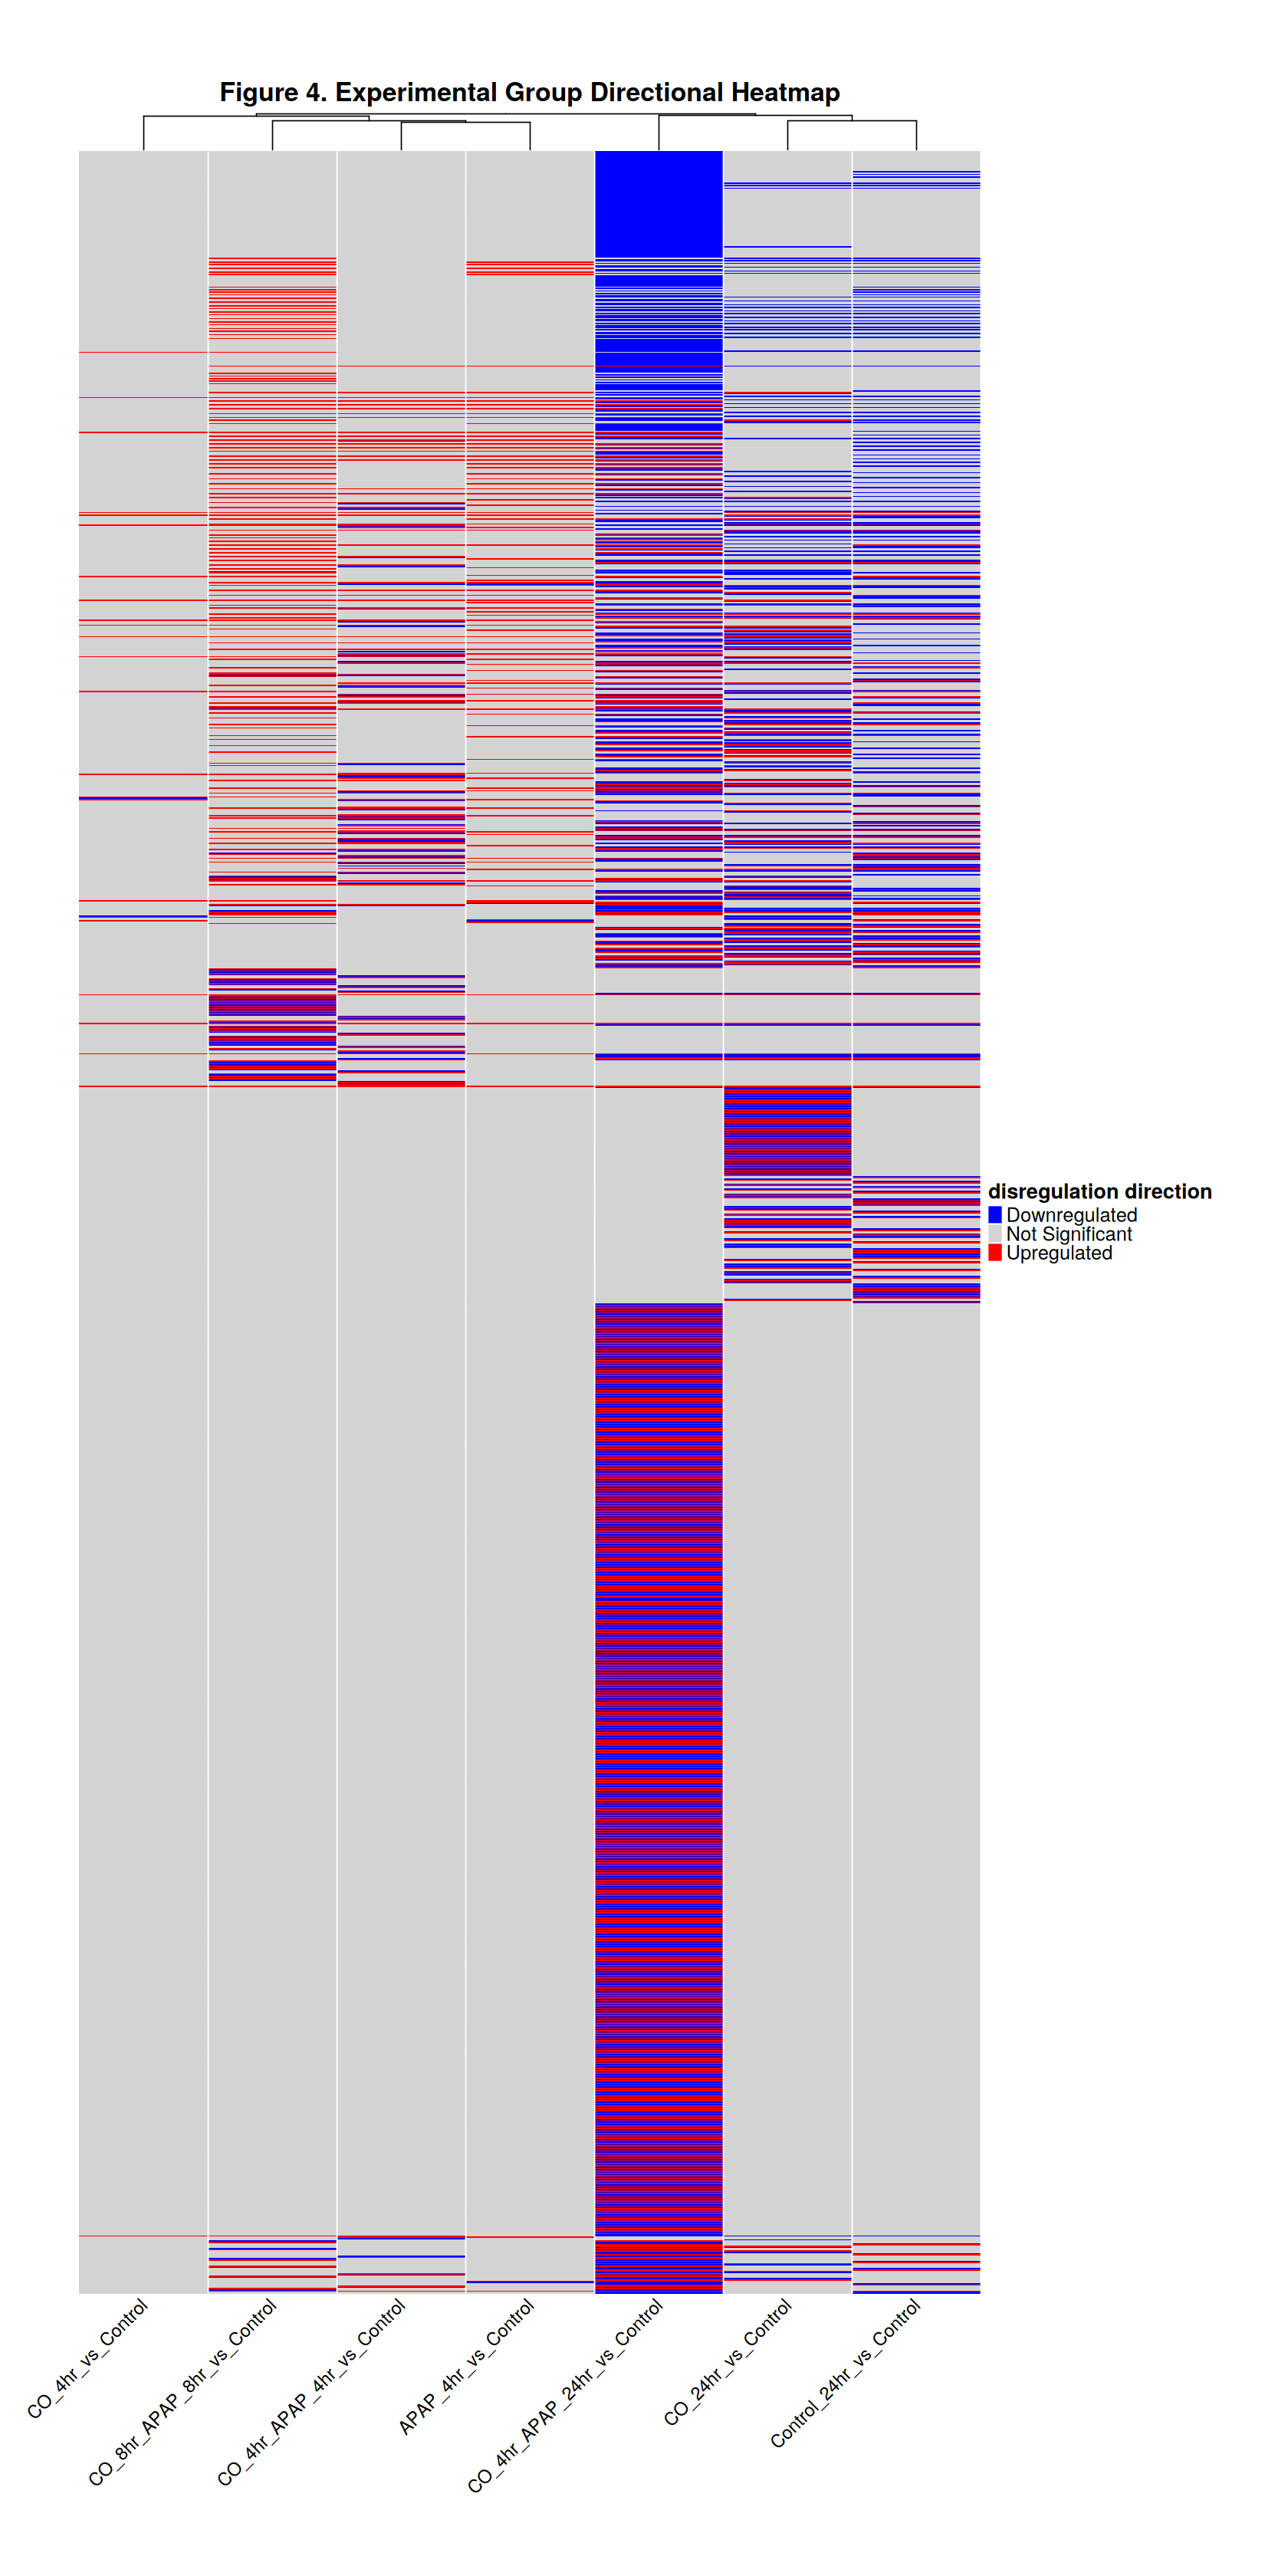

In [20]:
width <- 14
height <- 28
options(repr.plot.width=width, repr.plot.height=height)

row_dist <- as.dist(1 - proxy::simil(as.matrix(exp_dir_mat), method = "cosine"))
col_dist <- dist(t(as.matrix(exp_dir_mat)), method = function(a,b) signed_jaccard(a,b))

# Perform hierarchical clustering with average linkage
row_hclust <- hclust(row_dist, method = "average")
col_hclust <- hclust(col_dist, method = "average")

# Determine cell width and height dynamically
n_rows <- nrow(exp_dir_mat)
n_cols <- ncol(exp_dir_mat)

ht <- Heatmap(
  as.matrix(exp_dir_mat),
  name = "Significant",
  col = c("-1" = "blue", "0" = "lightgray", "1" = "red"),

  # row parameters
  cluster_rows = row_hclust,
  show_row_names = FALSE,
  cluster_columns = col_hclust,
  row_names_gp = gpar(fontsize = 8),
  show_row_dend = FALSE,


  # col parameters
  show_column_names = TRUE,
  column_names_rot = 45,                # angled column names
  column_title = "Figure 4. Experimental Group Directional Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold", lineheight = 8),
  column_title_side = "top",
  column_names_gp = gpar(fontsize = 14),
  width = unit(width * 0.7, "in"),

  # matrix parameters
  rect_gp = gpar(col = NA), # no default cell borders
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Draw vertical white line between columns
    x_right <- convertX(x + width/2, "npc", valueOnly = TRUE)
    y_bottom <- convertY(y - height/2, "npc", valueOnly = TRUE)
    y_top <- convertY(y + height/2, "npc", valueOnly = TRUE)

    grid.lines(
      x = unit(c(x_right, x_right), "npc"),
      y = unit(c(y_bottom, y_top), "npc"),
      gp = gpar(col = "white", lwd = 1)
    )
  },

  # legend parameters
  heatmap_legend_param = list(
    legend_height = unit(height * 0.25, "in"),
    title = "disregulation direction",
    at = c(-1, 0, 1),
    labels = c("Downregulated", "Not Significant", 'Upregulated'),
    title_gp = gpar(fontsize = 16, fontface = 'bold'),
    labels_gp = gpar(fontsize = 15)
  ), # adjust legend
)

draw(ht, padding = unit(c(6, 4, 6, 4), "lines"))

The clustered heatmap in Figure 4. shows the same data for the experimental group test contrasts as above but with direction encoded instead of ony encoding if each DEG candidate's expression is significant. The clustering in this case is on the direction of the change and therefore deploys slightly different measure for proximity for clustering the contrasts. For clustering genes, cosine similarity is again used to clarify similarity of pattern translated into directional distinctions while ignoring magnitude. Due to the directional nature of the data values, a signed Jaccard distance was used for contrast clustering. Like a traditional Jaccard it ignores instances where the contrasts share non-significant gene expression and only accounts for where there is commonality or difference between genes that have significant expression levels for a give pair of contrasts. Unlike traditional Jaccard, in signed Jaccard accommodates three potential values instead of two so there are more ways for agreement and disagreement to occur. 

Again, while the gene clustering was optimized for the type of data presented its values is in the organization of the genes presented for each contrast. In spite of more articulate data values in this plot, and a slightly different proximity measure used, the similarities between contrasts as captured by the clustering remain the same. The plot suggests that the acetaminophen tends to up-regulate most of its DEGs while contrasts for samples with exposure to the extract tend to include a greater amount of down-regulation.

#### **(1.b)** The following table and plots include aggregate data pertaining to direction of disregulation with respect to each contrast each contrast.



contrast                       up_count   down_count   induct_repres_ratio   signed_balance
----------------------------  ---------  -----------  --------------------  ---------------
CO_4hr_APAP_24hr_vs_Control         505          709             0.7122708       -0.1680395
CO_24hr_vs_Control                  151          214             0.7056075       -0.1726027
Control_24hr_vs_Control              94          191             0.4921466       -0.3403509
CO_4hr_APAP_4hr_vs_Control          101           52             1.9423077        0.3202614
CO_8hr_APAP_8hr_vs_Control          182           46             3.9565217        0.5964912
CO_4hr_vs_Control                    24            2            12.0000000        0.8461538
APAP_4hr_vs_Control                  97            4            24.2500000        0.9207921


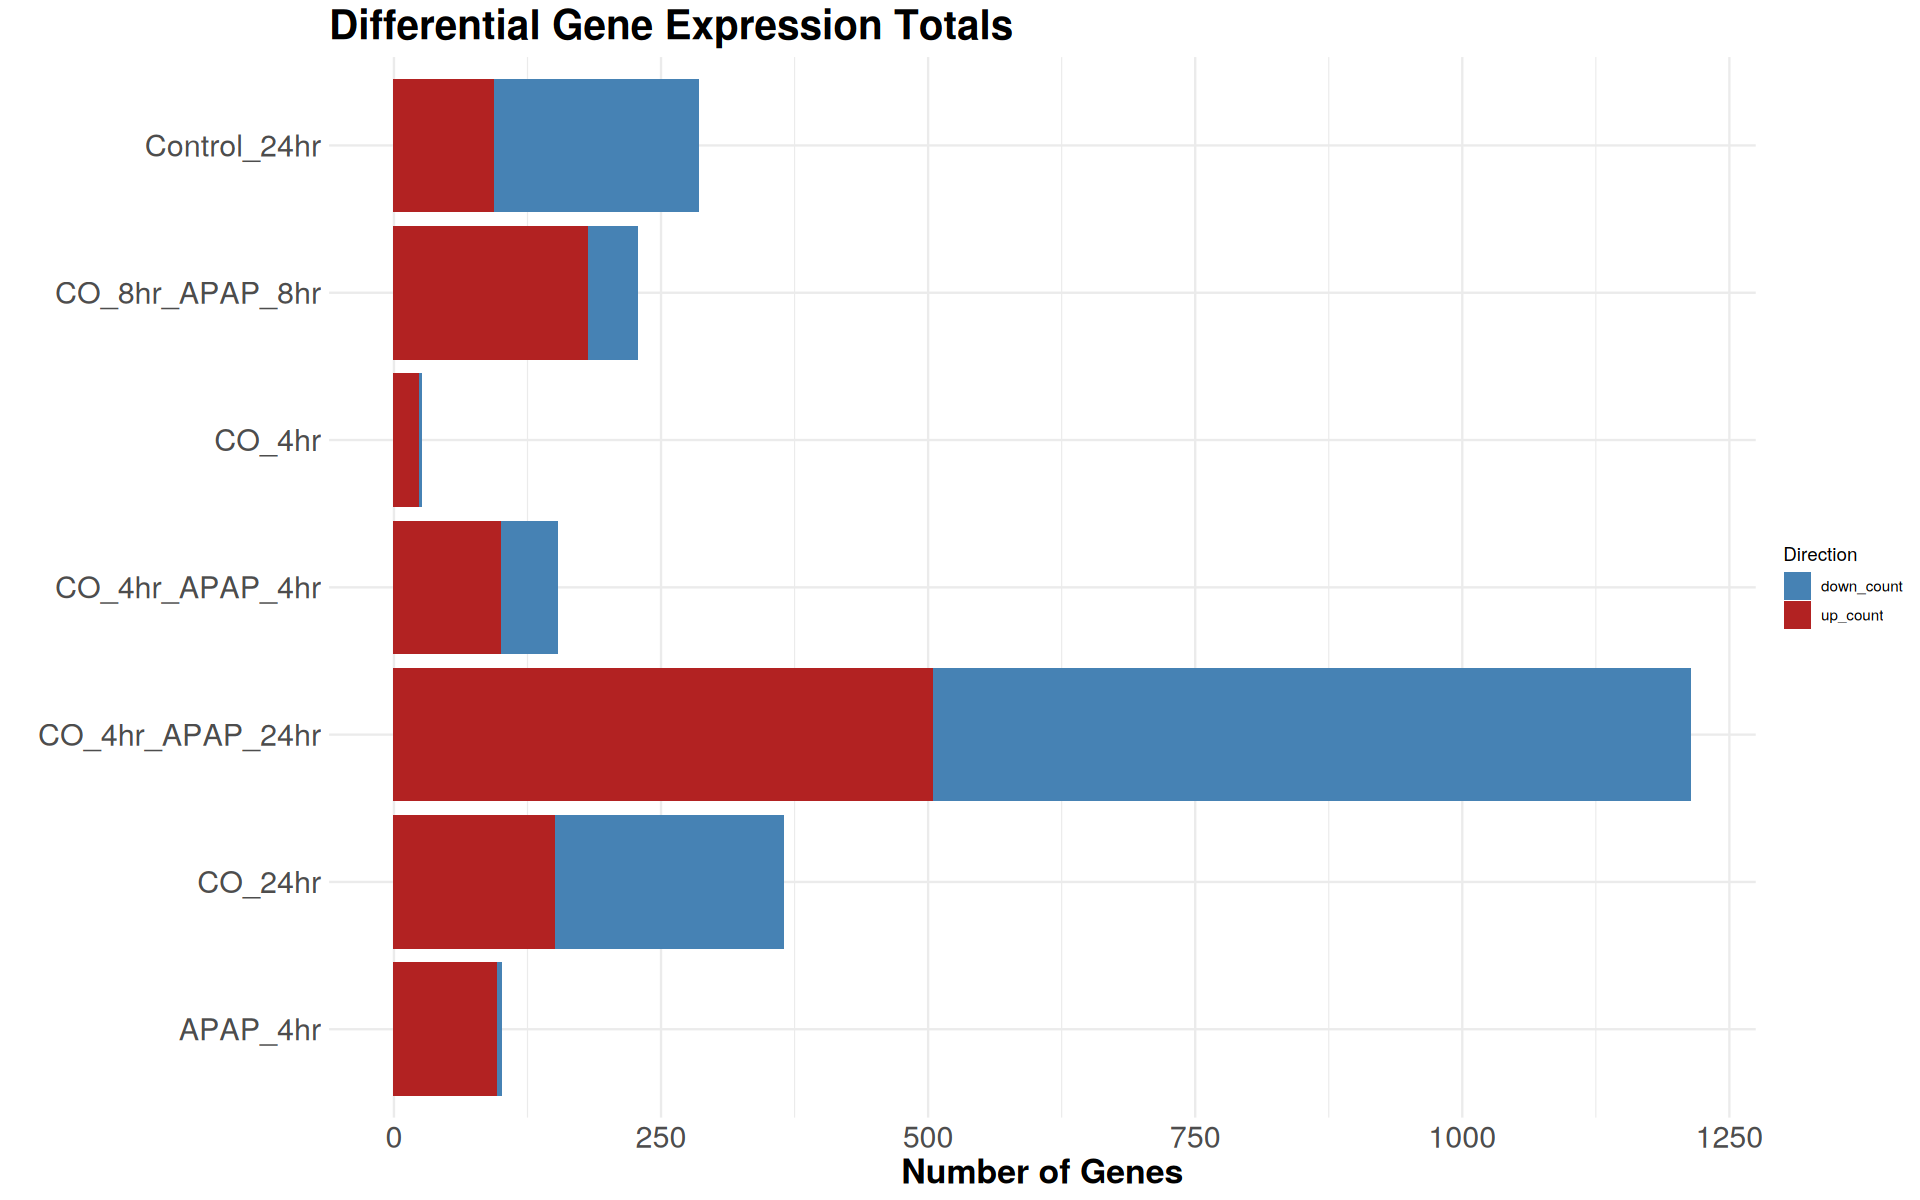

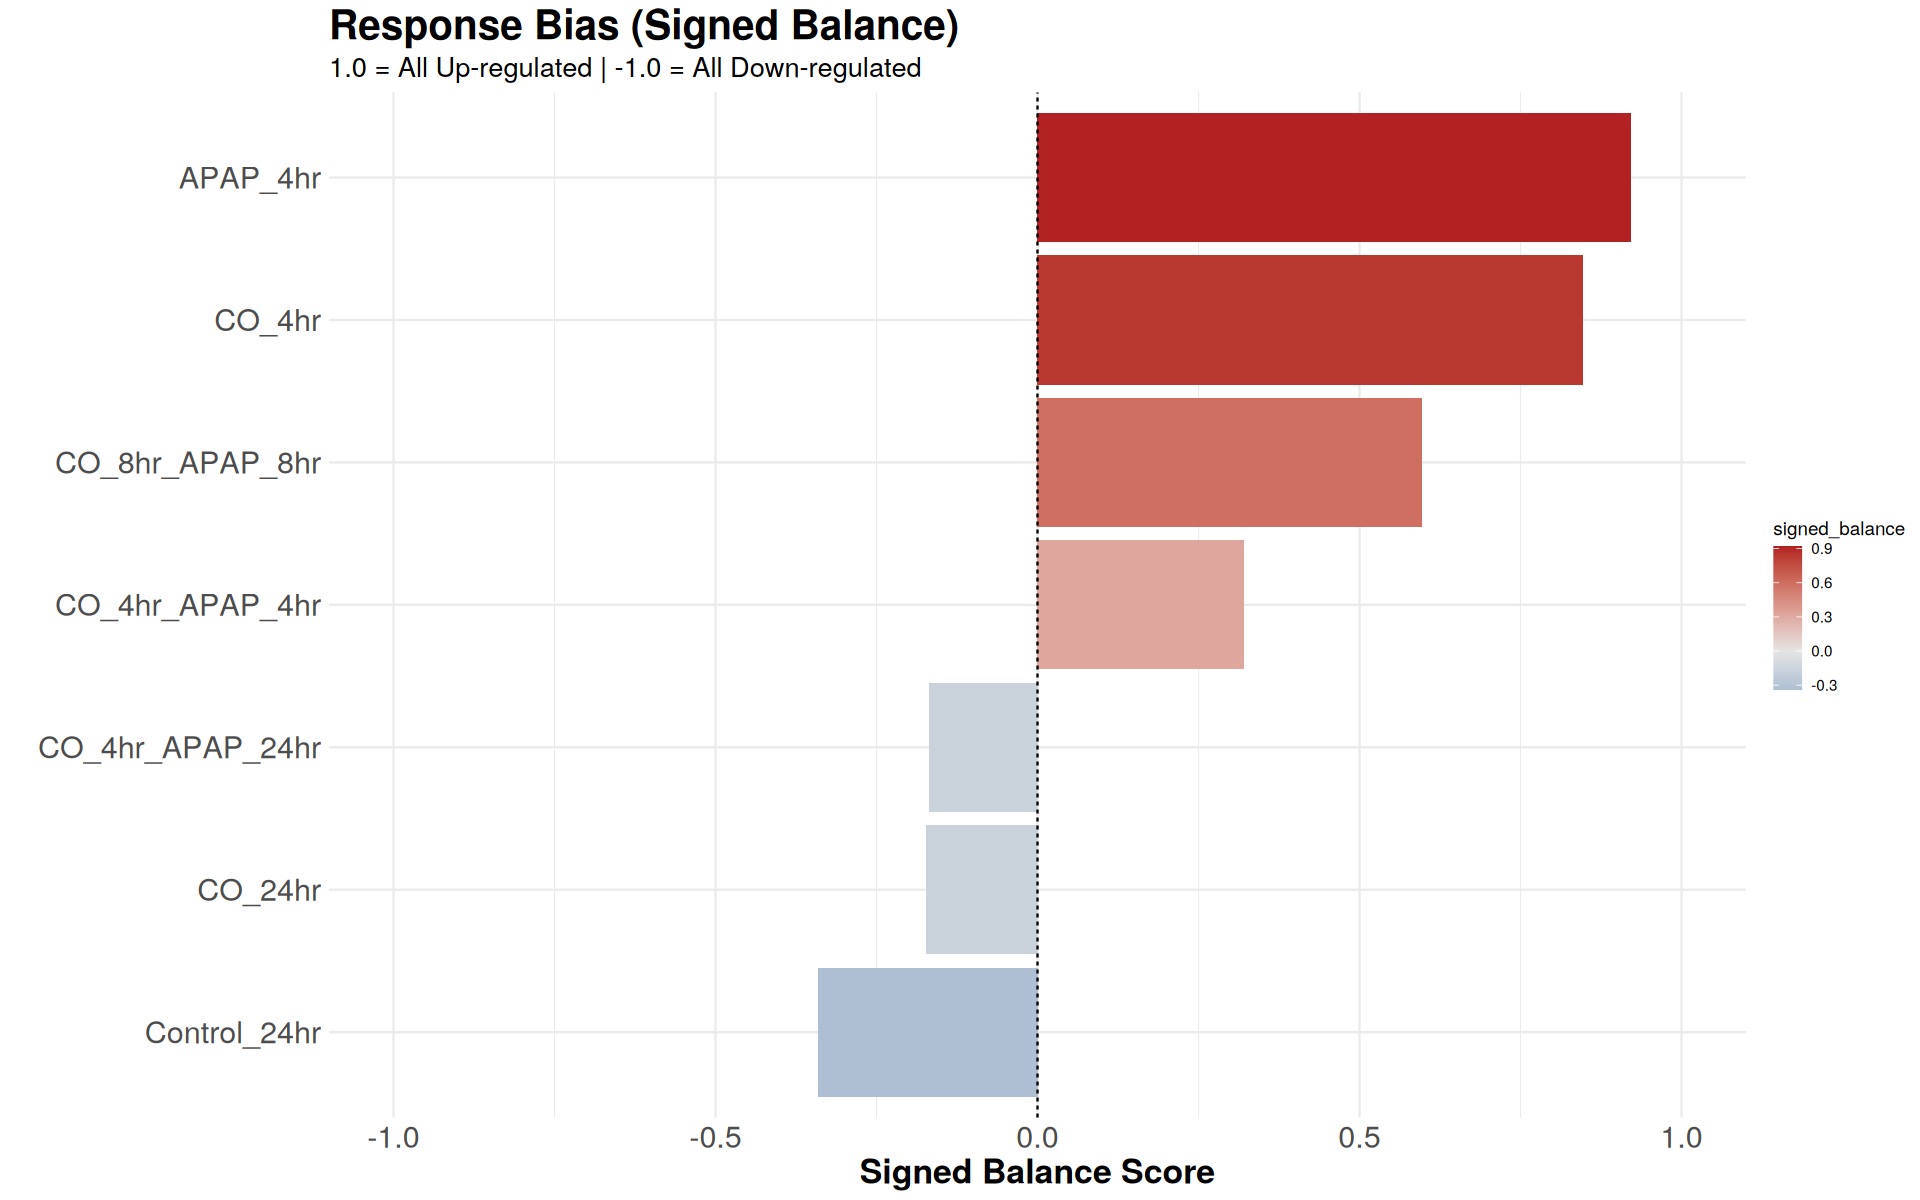

In [ ]:
options(repr.plot.width=16, repr.plot.height= 10)
contrasts <- colnames(exp_dir_mat)
# contrasts <- gsub("_vs_Control", "", contrasts)
up_counts <- sapply(contrasts, function(x) {
  contrast <- exp_dir_mat[[x]]
  upcount <- sum(contrast == 1)
})
down_counts <- sapply(contrasts, function(x) {
  contrast <- exp_dir_mat[[x]]
  downcount <- sum(contrast == -1)
})
induction_repression_ratio <- up_counts / down_counts

signed_balances <- (up_counts - down_counts) / (up_counts + down_counts)

balance_df <- data.frame(
  contrast = contrasts,
  up_count = up_counts,
  down_count = down_counts,
  induct_repres_ratio = induction_repression_ratio,
  signed_balance = signed_balances,
  row.names = NULL
)
print(kable(balance_df, format = "pandoc"))

plot_data <- balance_df %>%
  pivot_longer(cols = c(up_count, down_count), 
               names_to = "Direction", 
               values_to = "Count")

ggplot(plot_data, aes(x = contrast, y = Count, fill = Direction)) +
  geom_bar(stat = "identity") +
  coord_flip() + # Flip for readability of contrast names
  scale_fill_manual(values = c("down_count" = "steelblue", "up_count" = "firebrick")) +
  theme_minimal() +
  labs(title = "Gene Directional Expression Totals", x = "", y = "Number of Genes") +
  scale_x_discrete(
    breaks = contrasts, # The original data values
    labels = gsub("_vs_Control", "", contrasts)
  ) +
  theme(
  # axis.text.x = element_text(angle = 30, hjust = 1),
  plot.title = element_text(size = 24, face = "bold"),
  plot.subtitle = element_text(size = 16),
  axis.title = element_text(size = 20, face = "bold"),
  axis.text = element_text(size = 18)
)

ggplot(balance_df, aes(x = reorder(contrast, signed_balance), y = signed_balance)) +
  geom_col(aes(fill = signed_balance)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_flip() +
  scale_fill_gradient2(low = "steelblue", mid = "grey90", high = "firebrick", midpoint = 0) +
  ylim(-1, 1) +
  theme_minimal() +
  labs(title = "Response Bias (Signed Balance)", 
      subtitle = "1.0 = All Up-regulated | -1.0 = All Down-regulated",
      x = "", y = "Signed Balance Score") +
  scale_x_discrete(
    breaks = contrasts, # The original data values
    labels = gsub("_vs_Control", "", contrasts)
  ) +
  theme(
    # axis.text.x = element_text(angle = 30, hjust = 1),
    plot.title = element_text(size = 24, face = "bold"),
    plot.subtitle = element_text(size = 16),
    axis.title = element_text(size = 20, face = "bold"),
    axis.text = element_text(size = 18)
  )


There is mixed evidence in the above table and plots for a general repressive effect from extract exposure. Four hour exposure to only the extract had the second most positive skewed sign balance, yet when combined with acetaminophen at the same interval of exposure, there is a much more neutral balance than what is seen for the four hour acetaminophen exposure alone. There is the greatest evidence for the medium itself being the most repressive agent, while it is clear that acetaminophen is the most inductive agent.

#### **(1.c)** Below is a list of DEGs that reverse direction of disregulation across the experimental group contrasts. (Potential Regulatory Genes of interest)

In [37]:
signal_reversal_idx <- apply(exp_dir_mat, 1, function(x) {
  reversal <- any(x == 1) & any(x == -1)
})

reversed_degs <- rownames(exp_dir_mat)[signal_reversal_idx]

reversedDEGs_df <- data.frame("Regulatory Gene Candidates" = reversed_degs, check.names = FALSE)

print(kable(reversedDEGs_df, format = 'pandoc'))



 Regulatory Gene Candidates 
 ---------------------------
 ENSG00000075624.17         
 ENSG00000184009.13         
 ENSG00000173812.11         
 ENSG00000137801.11         
 ENSG00000130066.17         
 ENSG00000189043.10         
 ENSG00000181163.14         
 ENSG00000109475.18         
 ENSG00000145050.19         
 ENSG00000169567.13         
 ENSG00000109321.11         
 ENSG00000143947.15         
 ENSG00000291237.1          
 ENSG00000171365.17         
 ENSG00000026025.16         
 ENSG00000142871.18         
 ENSG00000110958.16         
 ENSG00000166923.12         
 ENSG00000198417.7          
 ENSG00000101057.16         
 ENSG00000108671.11         
 ENSG00000119318.13         
 ENSG00000007944.16         
 ENSG00000138061.13         
 ENSG00000161970.15         
 ENSG00000253352.10         
 ENSG00000100906.12         
 ENSG00000171206.17         
 ENSG00000132646.11         
 ENSG00000133872.14         
 ENSG00000118276.12         
 ENSG00000164032.12         
 ENSG0000000

#### (1.d) The following is a correlation matrix generated from the direction matrix.

In [38]:
numeric_mat <- apply(exp_dir_mat, 2, as.numeric)
rownames(numeric_mat) <- rownames(exp_dir_mat)
colnames(numeric_mat) <- gsub("_vs_Control", "", colnames(numeric_mat))

dir_cor_mat <- cor(numeric_mat)
dir_cor_mat

,CO_4hr_APAP_24hr,CO_24hr,Control_24hr,CO_4hr_APAP_4hr,CO_8hr_APAP_8hr,CO_4hr,APAP_4hr
CO_4hr_APAP_24hr,1.00000000,0.17276758,0.17416225,0.11266432,0.1322521,0.04359062,0.1808369
CO_24hr,0.17276758,1.00000000,0.35939800,0.08020003,0.1318714,0.11193757,0.1202243
Control_24hr,0.17416225,0.35939800,1.00000000,0.09609111,0.1124880,0.09728532,0.1238159
CO_4hr_APAP_4hr,0.11266432,0.08020003,0.09609111,1.00000000,0.3643035,0.26217077,0.4422468
CO_8hr_APAP_8hr,0.13225206,0.13187138,0.11248803,0.36430354,1.0000000,0.27096173,0.3713428
CO_4hr,0.04359062,0.11193757,0.09728532,0.26217077,0.2709617,1.00000000,0.2376275
APAP_4hr,0.18083695,0.12022427,0.12381594,0.44224675,0.3713428,0.23762750,1.0000000


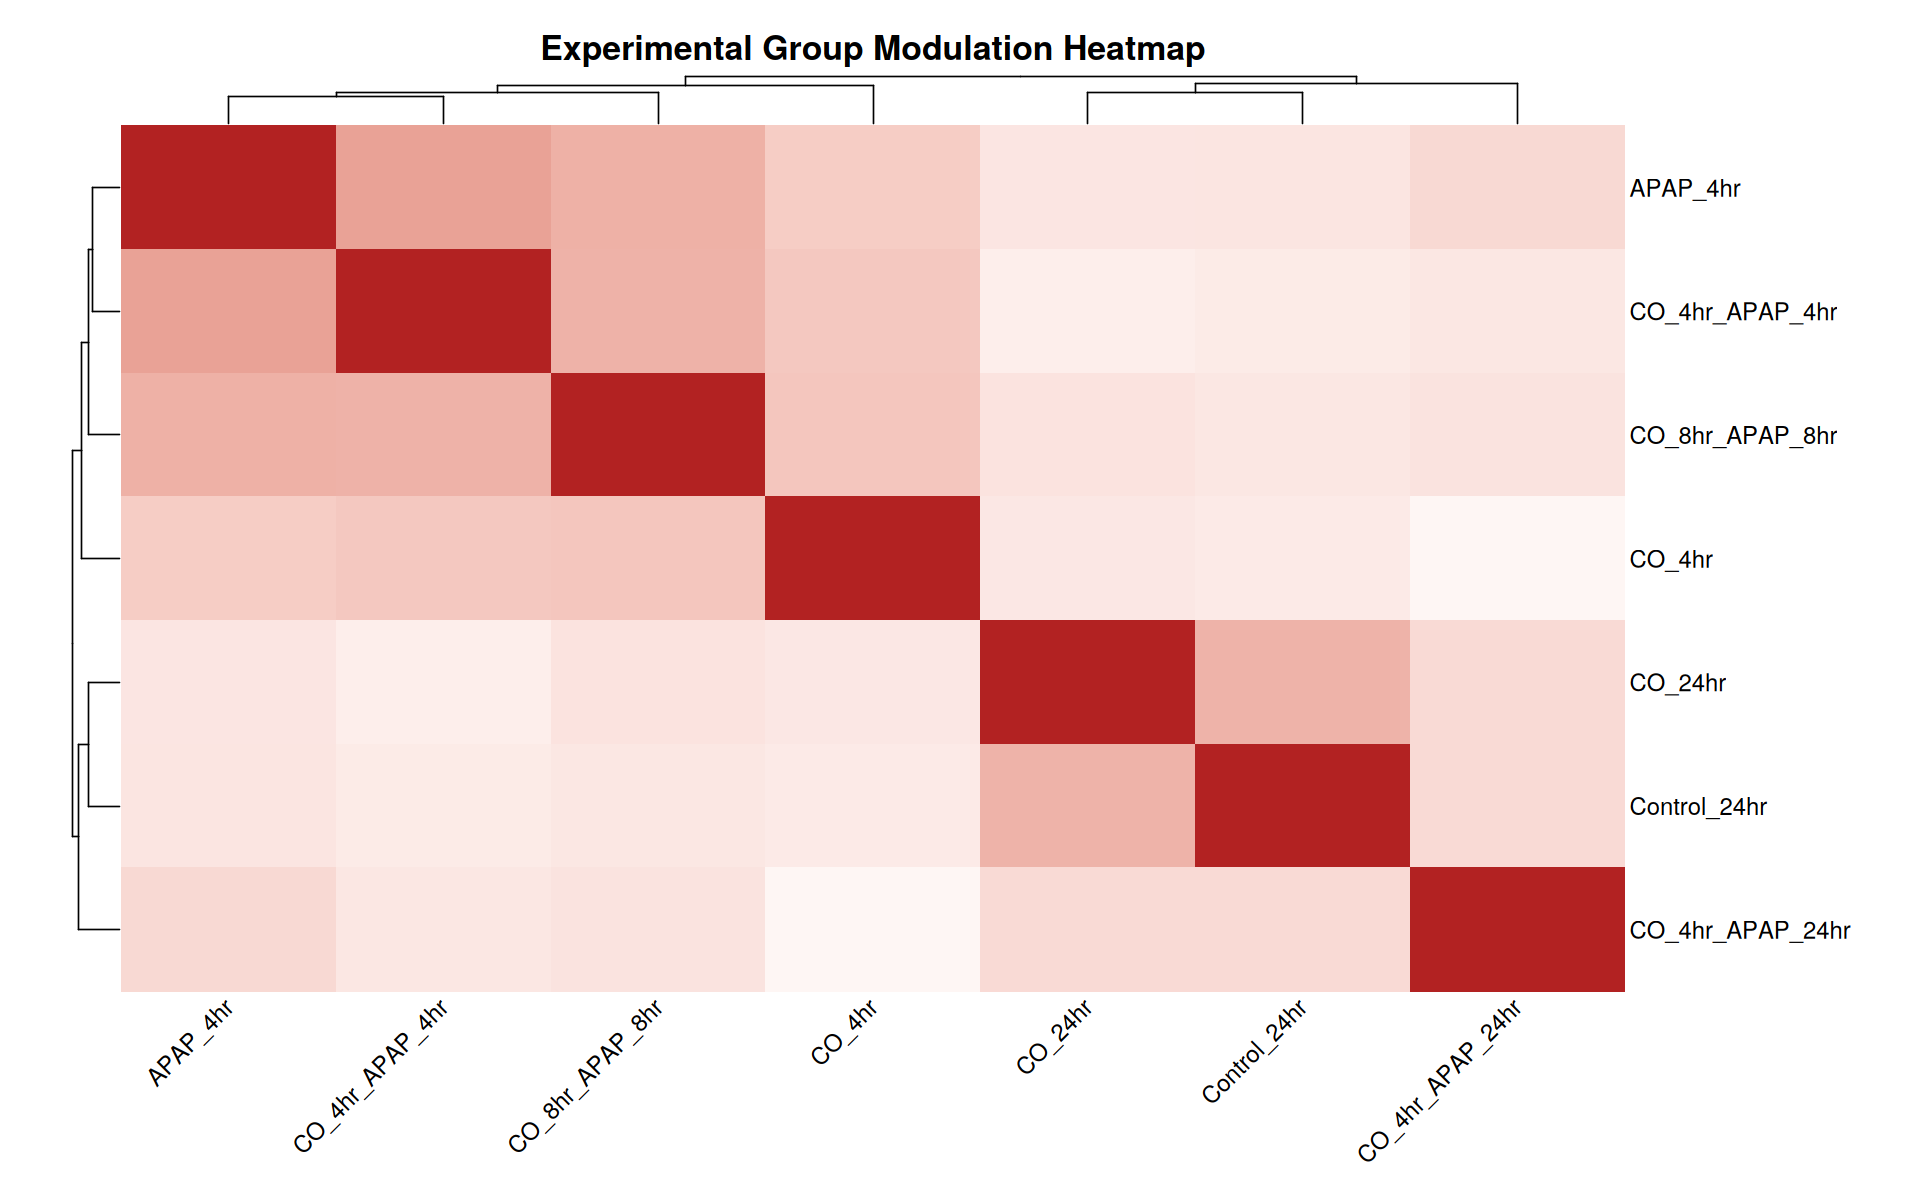

In [ ]:

col_fun <- colorRamp2(
  c(-1, 0, 1),
  c("steelblue", "white", "firebrick")
)

ht <- Heatmap(
  dir_cor_mat,
  name = "correlation",
  col = col_fun,
  column_names_rot = 45,
  column_title = "Experimental Group Modulation Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold"),
  column_title_side = "top",
  show_heatmap_legend = FALSE,   
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 14),
)

draw(ht, padding = unit(c(2, 4, 2, 4), "lines"))

The above correlation heatmap indicates all modulation is synergistic rather than antagonystic between the treatment groups. Focusing on the 4 hour exposure groups, the correlations are:  

- $CO_{4hr}\ vs\ APAP_{4hr}\ \approx 0.23$
- $CO_{4hr}\ vs\ CO+APAP_{4hr}\ \approx 0.25$
- $APAP_{4hr}\ vs\ CO+APAP_{4hr}\ \approx 0.43$

This suggests:
1. The treatments are largely independent at least at 4 hours of exposure: the low correlation indicates that there are few genes that regulated in the same direction by the treatments alone relative to the set of genes that are being disregulated

1. The increase in correlation between the extract alone and the combined treatment does indicate some interactive effect where the combined effect of the treatments is not just additive. 

1. However, the combined treatment shares more directionality with acetaminophen alone than with the extract alone.

Collectively, this indicates that there is evidence for non-additive interaction with neither of the individual treatments fully explaining the expression of the combined treatments. The consistently low correlations indicate that the treatments are largely independent with respect to the direction of disregulation. Different observations at different exposure levels could identify other trends but ability to assess independence at other exposure intervals is limited by successful samples. If there was higher correlation between the combined 8 hour exposure and the combined 4 hour exposure, there might be some room for insight from determining genes that are exclusive to the combined 8 hour contrast relative to the 4 hour contrasts for only one treatment. Because the correlation score for the 8 hour combined contrast and combined for hour contrast is $\approx 0.36$ the potential for exclusive genes in combined contrast relative to the 

The there is only one DEG associated with the 4 hour combined treatment exposure that is not in the 4 hour exposures for each individual treatment (outputted below). This is consistent with the UpSet plot which identified one gene unique to the dataset


In [58]:
interaction_genes <- rownames(intersect_df[intersect_df$exclusive_intersection == 'CO_4hr_APAP_4hr-CO_4hr-APAP_4hr',])
interaction_genes <- unique(gsub("(\\.[0-9]+)\\.[0-9]+$", "\\1", interaction_genes))
interaction_genes

[1] "ENSG00000148677.7"